In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings, os, time as _time, json as json_mod

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
warnings.filterwarnings('ignore')

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')
OUT_DIR = Path('output/S3_polyfit')
OUT_DIR.mkdir(parents=True, exist_ok=True)

cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')
cases['snr_float'] = cases['snr'].apply(lambda x: float(x))

pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']
case_idx_map = pd.Series(np.arange(len(cases)), index=cases['case_id']).to_dict()

df = cases.merge(
    metrics[['case_id', 'MIC', 'distance_correlation', 'pearson_r', 'spearman_rho']],
    on='case_id', how='inner',
)

null_data = df[df['family_id'] == 'Null'].copy()

variants = {}
for vname in ['strong', 'mild']:
    v = df[df['variant_level'] == vname].copy()
    v = pd.concat([v, null_data], ignore_index=True)
    v = v[np.isfinite(v['snr_float'])].copy()
    v['abs_rho'] = v['spearman_rho'].abs()
    v['abs_r']   = v['pearson_r'].abs()
    variants[vname] = v

print(f'Strong: {len(variants["strong"]):,} rows')
print(f'Mild:   {len(variants["mild"]):,} rows')
STEP4_BIC_THRESHOLD = 6.0

Strong: 55,350 rows
Mild:   55,350 rows


In [2]:
# ══════════════════════════════════════════════════════
#  Human annotations — both variants
# ══════════════════════════════════════════════════════

ANNOT = {
    'strong': {
        'NO_GLOBAL': ['F07', 'F08', 'F19', 'F20'],
        'CLEAR_SNR_S1': {
            'F01': 3.0, 'F02': 3.0,
            'F03': 2.0, 'F04': 2.0, 'F05': 2.0, 'F06': 2.0,
            'F09': 2.0, 'F10': 2.0, 'F11': 2.0, 'F12': 2.0,
            # Boundary lies between the displayed SNR=10 (actual 10.217) and SNR=12 (11.657).
            'F13': 11.0, 'F14': 11.0, 'F15': 10.5, 'F16': 10.5,
            'F17': 1.0, 'F18': 1.0, 'F19': 1.0, 'F20': 1.0,
            'F21': 3.0, 'F22': 3.0, 'F23': 8.0, 'F24': 8.0,
            'F25': 8.0, 'F26': 8.0,
        },
        'THRESHOLD_SNR_S1': {
            'F01': 0.3, 'F02': 0.3,
            'F03': 0.3, 'F04': 0.3, 'F05': 0.3, 'F06': 0.3,
            'F09': 0.3, 'F10': 0.3, 'F11': 0.3, 'F12': 0.3,
            'F13': 0.0, 'F14': 0.0, 'F15': 10.5, 'F16': 10.5,
            'F17': 0.3, 'F18': 0.3, 'F19': 0.1, 'F20': 0.1,
            'F21': 0.3, 'F22': 0.3, 'F23': 3.0, 'F24': 3.0,
            'F25': 1.0, 'F26': 1.0,
        },
        'SIMPLE_FAM': ['F01','F02','F03','F04','F05','F06','F09','F10','F11','F12'],
        'UNCERTAIN_S2': ['F13','F14','F15','F16'],
        'COMPLEX_FAM': ['F17','F18','F21','F22','F23','F24','F25','F26'],
        'CLEAR_SNR_S2': {
            'F01': 2.0, 'F02': 2.0, 'F03': 2.0, 'F04': 2.0,
            'F05': 3.0, 'F06': 3.0,
            'F09': 3.0, 'F10': 3.0, 'F11': 3.0, 'F12': 3.0,
            'F13': 15.0, 'F14': 15.0,
        },
        'THRESHOLD_SNR_S2': {
            'F01': 0.3, 'F02': 0.3, 'F03': 0.3, 'F04': 0.3,
            'F05': 0.5, 'F06': 0.5,
            'F09': 0.5, 'F10': 0.5, 'F11': 0.5, 'F12': 0.5,
            'F13': 0.0, 'F14': 0.0,
        },
        'STRONG_MONO': ['F01','F02','F03','F04','F05','F06','F09','F10','F11','F12'],
        'UNCERTAIN_MONO': ['F15', 'F16'],
        'UNCERTAIN_MONO_MIN_SNR': {'F15': 10.0, 'F16': 10.0},
        'WEAK_MONO': ['F13', 'F14'],
        'CLEAR_SNR_S3': {
            'F01': 10.0, 'F02': 10.0, 'F03': 10.0, 'F04': 10.0,
            'F05': 10.0, 'F06': 10.0,
            'F09': 10.0, 'F10': 10.0, 'F11': 10.0, 'F12': 10.0,
        },
        'THRESHOLD_SNR_S3': {
            'F01': 0.0, 'F02': 0.0, 'F03': 0.0, 'F04': 0.0,
            'F05': 0.0, 'F06': 0.0,
            'F09': 0.0, 'F10': 0.0, 'F11': 0.0, 'F12': 0.0,
        },
        'LINEAR_FAM': ['F01', 'F02'],
        'UNCERTAIN_LINEAR': [],
        'NONLINEAR_FAM': ['F03','F04','F05','F06','F09','F10','F11','F12','F15','F16'],
        'CLEAR_SNR_S4': {'F01': 0.0, 'F02': 0.0},
        'THRESHOLD_SNR_S4': {'F01': 0.0, 'F02': 0.0},
        'CURVATURE_FAMILY_CLASS': {
            'F03': 'Convex',   'F04': 'Concave',
            'F05': 'Concave',  'F06': 'Convex',
            'F09': 'Concave',  'F10': 'Convex',
            'F11': 'Convex',   'F12': 'Concave',
            'F13': 'Inflected','F14': 'Inflected',
            'F15': 'Inflected','F16': 'Inflected',
        },
    },
    'mild': {
        'NO_GLOBAL': ['F19', 'F20'],
        'CLEAR_SNR_S1': {
            'F01': 5.0, 'F02': 5.0,
            'F03': 5.0, 'F04': 5.0, 'F05': 5.0, 'F06': 5.0,
            'F07': 5.0, 'F08': 5.0,
            'F09': 5.0, 'F10': 5.0, 'F11': 5.0, 'F12': 5.0,
            'F13': 15.0, 'F14': 15.0, 'F15': 8.0, 'F16': 8.0,
            'F17': 1.0, 'F18': 1.0, 'F19': 1.0, 'F20': 1.0,
            # 1.9 includes the displayed SNR=2 column (actual 1.965).
            'F21': 1.9, 'F22': 1.9, 'F23': 10.0, 'F24': 8.0,
            'F25': 8.0, 'F26': 8.0,
        },
        'THRESHOLD_SNR_S1': {
            # Let displayed SNR=2 for F01 remain uncertain so it can reach Step 4.
            'F01': 1.9, 'F02': 2.0,
            'F03': 2.0, 'F04': 2.0, 'F05': 2.0, 'F06': 2.0,
            'F07': 2.0, 'F08': 2.0,
            'F09': 2.0, 'F10': 2.0, 'F11': 2.0, 'F12': 2.0,
            'F13': 5.0, 'F14': 5.0, 'F15': 5.0, 'F16': 5.0,
            'F17': 0.3, 'F18': 0.3, 'F19': 0.1, 'F20': 0.1,
            'F21': 0.3, 'F22': 0.3, 'F23': 3.0, 'F24': 3.0,
            'F25': 1.0, 'F26': 1.0,
        },
        'SIMPLE_FAM': ['F01','F02','F03','F04','F05','F06','F07','F08','F09','F10','F11','F12'],
        'UNCERTAIN_S2': ['F13','F14','F15','F16'],
        'COMPLEX_FAM': ['F17','F18','F21','F22','F23','F24','F25','F26'],
        'CLEAR_SNR_S2': {
            'F01': 2.0, 'F02': 2.0, 'F03': 2.0, 'F04': 2.0,
            'F07': 2.0, 'F08': 2.0,
            'F05': 3.0, 'F06': 3.0,
            'F09': 3.0, 'F10': 3.0, 'F11': 3.0, 'F12': 3.0,
            'F13': 15.0, 'F14': 15.0,
        },
        'THRESHOLD_SNR_S2': {
            'F01': 0.3, 'F02': 0.3, 'F03': 0.3, 'F04': 0.3,
            'F07': 0.3, 'F08': 0.3,
            'F05': 0.5, 'F06': 0.5,
            'F09': 0.5, 'F10': 0.5, 'F11': 0.5, 'F12': 0.5,
        },
        'STRONG_MONO': ['F01','F02','F03','F04','F05','F06','F07','F08','F09','F10','F11','F12'],
        'UNCERTAIN_MONO': ['F13', 'F14', 'F15', 'F16'],
        'UNCERTAIN_MONO_MIN_SNR': {'F15': 10.0, 'F16': 10.0},
        'WEAK_MONO': [],
        'CLEAR_SNR_S3': {
            'F01': 10.0, 'F02': 10.0, 'F03': 10.0, 'F04': 10.0,
            'F05': 10.0, 'F06': 10.0, 'F07': 10.0, 'F08': 10.0,
            'F09': 10.0, 'F10': 10.0, 'F11': 10.0, 'F12': 10.0,
        },
        'THRESHOLD_SNR_S3': {
            'F01': 0.0, 'F02': 0.0, 'F03': 0.0, 'F04': 0.0,
            'F05': 0.0, 'F06': 0.0, 'F07': 0.0, 'F08': 0.0,
            'F09': 0.0, 'F10': 0.0, 'F11': 0.0, 'F12': 0.0,
        },
        'LINEAR_FAM': ['F01', 'F02'],
        'UNCERTAIN_LINEAR': ['F03', 'F04', 'F05', 'F06', 'F11', 'F12'],
        'NONLINEAR_FAM': ['F07','F08','F09','F10','F13','F14','F15','F16'],
        # F01/F02 are labelled clearly linear (green) at every SNR in Step 4.
        'CLEAR_SNR_S4': {'F01': 0.0, 'F02': 0.0},
        'THRESHOLD_SNR_S4': {'F01': 0.0, 'F02': 0.0},
        'CURVATURE_FAMILY_CLASS': {
            'F03': 'Convex',   'F04': 'Concave',
            'F05': 'Concave',  'F06': 'Convex',
            # y=1-exp(-kx) has f''<0; negating it reverses the curvature sign.
            'F07': 'Concave',  'F08': 'Convex',
            'F09': 'Concave',  'F10': 'Convex',
            'F11': 'Convex',   'F12': 'Concave',
            'F13': 'Inflected','F14': 'Inflected',
            'F15': 'Inflected','F16': 'Inflected',
        },
    },
}

print('Annotations loaded for both variants')
for vn in ['strong', 'mild']:
    a = ANNOT[vn]
    print(f'\n{vn}:')
    print(f'  S1: NO_GLOBAL={a["NO_GLOBAL"]}, {len(a["CLEAR_SNR_S1"])} families annotated')
    print(f'  S2: {len(a["SIMPLE_FAM"])} simple, {len(a["UNCERTAIN_S2"])} uncertain, {len(a["COMPLEX_FAM"])} complex')
    print(f'  S3: {len(a["STRONG_MONO"])} strong, {len(a["UNCERTAIN_MONO"])} uncertain, {len(a["WEAK_MONO"])} weak')
    print(f'  S4: {len(a["LINEAR_FAM"])} linear, {len(a["UNCERTAIN_LINEAR"])} uncertain, {len(a["NONLINEAR_FAM"])} nonlinear')
    print(f'  S5: {len(a["CURVATURE_FAMILY_CLASS"])} curvature families: {a["CURVATURE_FAMILY_CLASS"]}')

# Verify that hand-written Convex/Concave expectations match the original case metadata.
source_curvature = (cases[['family_id', 'curvature']].drop_duplicates('family_id')
                    .set_index('family_id')['curvature'].to_dict())
for fid in ['F03','F04','F05','F06','F07','F08','F09','F10','F11','F12']:
    for vn in ['strong', 'mild']:
        if fid in ANNOT[vn]['CURVATURE_FAMILY_CLASS']:
            assert ANNOT[vn]['CURVATURE_FAMILY_CLASS'][fid].lower() == source_curvature[fid]

# Two Lines (F23/F24) are complex families and must be filtered before mild Step 4.
mild_s4_families = set(ANNOT['mild']['LINEAR_FAM'] + ANNOT['mild']['UNCERTAIN_LINEAR'] + ANNOT['mild']['NONLINEAR_FAM'])
assert not ({'F23', 'F24'} & mild_s4_families), 'Two Lines must be filtered before mild Step 4'

Annotations loaded for both variants

strong:
  S1: NO_GLOBAL=['F07', 'F08', 'F19', 'F20'], 24 families annotated
  S2: 10 simple, 4 uncertain, 8 complex
  S3: 10 strong, 2 uncertain, 2 weak
  S4: 2 linear, 0 uncertain, 10 nonlinear
  S5: 12 curvature families: {'F03': 'Convex', 'F04': 'Concave', 'F05': 'Concave', 'F06': 'Convex', 'F09': 'Concave', 'F10': 'Convex', 'F11': 'Convex', 'F12': 'Concave', 'F13': 'Inflected', 'F14': 'Inflected', 'F15': 'Inflected', 'F16': 'Inflected'}

mild:
  S1: NO_GLOBAL=['F19', 'F20'], 26 families annotated
  S2: 12 simple, 4 uncertain, 8 complex
  S3: 12 strong, 4 uncertain, 0 weak
  S4: 2 linear, 6 uncertain, 8 nonlinear
  S5: 14 curvature families: {'F03': 'Convex', 'F04': 'Concave', 'F05': 'Concave', 'F06': 'Convex', 'F07': 'Concave', 'F08': 'Convex', 'F09': 'Concave', 'F10': 'Convex', 'F11': 'Convex', 'F12': 'Concave', 'F13': 'Inflected', 'F14': 'Inflected', 'F15': 'Inflected', 'F16': 'Inflected'}


In [3]:
# ══════════════════════════════════════════════════════
#  Utility functions
# ══════════════════════════════════════════════════════

def fuzzy_mu(z, L, U):
    return np.clip((z - L) / (U - L), 0.0, 1.0)

def fuzzy_and(*memberships):
    # AND = minimum when larger membership means stronger evidence.
    return np.minimum.reduce([np.asarray(mu, dtype=float) for mu in memberships])

def mse_fuzzy(L, U, vals, labels):
    return float(np.mean((np.clip((vals - L) / (U - L), 0, 1) - labels) ** 2))

def grid_search_fuzzy(vals, labels, L_lo, L_hi, L_step, gap, U_hi,
                       decreasing=False, name=''):
    _ts = _time.time()
    coarse = max(L_step * 10, (L_hi - L_lo) / 25)
    best_mse, bL, bU = np.inf, L_lo, L_lo + gap
    for Lc in np.arange(L_lo, L_hi, coarse):
        for Uc in np.arange(Lc + gap, U_hi, coarse):
            p = np.clip((vals - Lc) / (Uc - Lc), 0, 1)
            if decreasing: p = 1.0 - p
            m = float(np.mean((p - labels) ** 2))
            if m < best_mse:
                best_mse, bL, bU = m, float(Lc), float(Uc)
    margin = coarse * 3
    fL_arr = np.arange(max(L_lo, bL - margin), min(L_hi, bL + margin) + L_step, L_step)
    for L in fL_arr:
        U_arr = np.arange(max(L + gap, bU - margin), min(U_hi, bU + margin) + L_step, L_step)
        if len(U_arr) == 0: continue
        preds = np.clip((vals - L) / (U_arr[:, None] - L), 0, 1)
        if decreasing: preds = 1.0 - preds
        mses = np.mean((preds - labels) ** 2, axis=1)
        j = int(np.argmin(mses))
        if mses[j] < best_mse:
            best_mse, bL, bU = float(mses[j]), float(L), float(U_arr[j])
        del preds, mses
    if name:
        print(f'    {name} ({_time.time()-_ts:.2f}s): L={bL:.3f} U={bU:.3f} MSE={best_mse:.4f}')
    return bL, bU, best_mse

def bic_compare(x, y):
    order = np.argsort(x)
    xs = x[order].astype(np.float64)
    ys = y[order].astype(np.float64)
    x_mu, x_sd = xs.mean(), max(xs.std(), 1e-10)
    y_mu, y_sd = ys.mean(), max(ys.std(), 1e-10)
    xn = (xs - x_mu) / x_sd
    yn = (ys - y_mu) / y_sd
    n = len(xn)
    ss_tot = np.sum((yn - yn.mean()) ** 2)
    bics = {}
    for deg, k in [(1, 2), (2, 3), (3, 4)]:
        coeffs = np.polyfit(xn, yn, deg)
        pred = np.polyval(coeffs, xn)
        rss = np.sum((yn - pred) ** 2)
        bics[deg] = n * np.log(rss / n + 1e-30) + k * np.log(n)
    return bics[1] - min(bics[2], bics[3])

INTERIOR_MARGIN_S5 = 0.10
N_GRID_S5 = 200
F2_ABS_TOL_S5 = 0.02       # standardized f'' below this is treated as negligible
F2_REL_TOL_S5 = 0.05       # also ignore values below 5% of max |f''|
F2_MIN_SIGN_SUPPORT_S5 = 0.05  # each side of an inflection must cover >=5% of the grid
F2_MIN_ACTIVE_SUPPORT_S5 = 0.50

def curvature_evidence(x, y):
    order = np.argsort(x)
    xs = np.asarray(x, dtype=float)[order]
    ys = np.asarray(y, dtype=float)[order]
    xn = (xs - xs.mean()) / max(xs.std(), 1e-10)
    yn = (ys - ys.mean()) / max(ys.std(), 1e-10)
    coeffs = np.polyfit(xn, yn, 3)
    p = np.poly1d(coeffs)
    x_lo = xn.min() + INTERIOR_MARGIN_S5 * (xn.max() - xn.min())
    x_hi = xn.max() - INTERIOR_MARGIN_S5 * (xn.max() - xn.min())
    grid = np.linspace(x_lo, x_hi, N_GRID_S5)
    f2 = np.polyder(p, 2)(grid)
    f2_scale = float(np.max(np.abs(f2)))
    tol = max(F2_ABS_TOL_S5, F2_REL_TOL_S5 * f2_scale)
    signs = np.zeros_like(f2, dtype=int)
    signs[f2 > tol] = 1
    signs[f2 < -tol] = -1
    pos_support = float(np.mean(signs > 0))
    neg_support = float(np.mean(signs < 0))
    active_support = pos_support + neg_support
    nonzero_signs = signs[signs != 0]
    sign_changes = int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1])) if len(nonzero_signs) > 1 else 0

    if f2_scale < F2_ABS_TOL_S5 or active_support < F2_MIN_ACTIVE_SUPPORT_S5:
        curvature_type = 'Uncertain'
    elif (sign_changes >= 1
          and pos_support >= F2_MIN_SIGN_SUPPORT_S5
          and neg_support >= F2_MIN_SIGN_SUPPORT_S5):
        curvature_type = 'Inflected'
    elif pos_support >= F2_MIN_ACTIVE_SUPPORT_S5 and neg_support < F2_MIN_SIGN_SUPPORT_S5:
        curvature_type = 'Convex'
    elif neg_support >= F2_MIN_ACTIVE_SUPPORT_S5 and pos_support < F2_MIN_SIGN_SUPPORT_S5:
        curvature_type = 'Concave'
    else:
        curvature_type = 'Uncertain'
    return {
        'curvature_type': curvature_type,
        'f2_scale': f2_scale,
        'f2_pos_support': pos_support,
        'f2_neg_support': neg_support,
        'f2_sign_changes': sign_changes,
        'f2_tolerance': tol,
    }

# ── 通用图：实际 indicator/label + 分段线性 fuzzy gate ──
def plot_calibrated_gate(ax, values, human_labels, L, U, indicator_name, title,
                         alpha=0.5, hard_threshold=None, increasing=True):
    values = np.asarray(values, dtype=float)
    human_labels = np.asarray(human_labels, dtype=float)
    keep = np.isfinite(values) & np.isfinite(human_labels)
    values, human_labels = values[keep], human_labels[keep]

    rng = np.random.default_rng(42)
    point_styles = {
        0.0: ('No', '#d32f2f', 'x'),
        0.5: ('Uncertain', '#f57c00', 's'),
        1.0: ('Yes', '#2e7d32', 'o'),
    }
    for y_value, (name, color, marker) in point_styles.items():
        mask = np.isclose(human_labels, y_value)
        if not mask.any(): continue
        jitter = rng.uniform(-0.025, 0.025, mask.sum())
        ax.scatter(values[mask], human_labels[mask] + jitter,
                   c=color, marker=marker, s=22, alpha=0.32,
                   label=f'{name} (n={mask.sum()})', edgecolors='none', zorder=2)

    anchors = [np.nanmin(values), np.nanmax(values), L, U]
    if hard_threshold is not None: anchors.append(hard_threshold)
    lo, hi = min(anchors), max(anchors)
    if lo >= 0 and hi <= 1.05:
        x_min, x_max = 0.0, 1.0
    else:
        pad = 0.05 * max(hi - lo, 1e-9)
        x_min, x_max = lo - pad, hi + pad

    grid = np.linspace(x_min, x_max, 400)
    if increasing:
        mu_grid = np.clip((grid - L) / (U - L), 0.0, 1.0)
        alpha_x = L + alpha * (U - L)
    else:
        mu_grid = np.clip((U - grid) / (U - L), 0.0, 1.0)
        alpha_x = U - alpha * (U - L)

    ax.axvspan(L, U, color='#f57c00', alpha=0.08, label='Fuzzy range [L, U]', zorder=0)
    ax.plot(grid, mu_grid, color='black', lw=2.4,
            label=f'Piecewise μ: L={L:.3f}, U={U:.3f}', zorder=4)
    ax.axvline(L, color='#d32f2f', ls=':', lw=1.2, label=f'L={L:.3f}')
    ax.axvline(U, color='#2e7d32', ls=':', lw=1.2, label=f'U={U:.3f}')
    ax.axhline(alpha, color='#f57c00', ls='--', lw=1.1, label=f'α={alpha:.2f}')
    ax.axvline(alpha_x, color='#f57c00', ls='--', lw=1.1,
               label=f'α-cut at {indicator_name}={alpha_x:.3f}')
    if hard_threshold is not None:
        ax.axvline(hard_threshold, color='gray', ls='--', lw=1.0, alpha=0.7,
                   label=f'Hard={hard_threshold:g}')

    ax.set_xlabel(indicator_name, fontsize=11)
    ax.set_ylabel('μ / human label', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(x_min - 0.02 * (x_max - x_min), x_max + 0.02 * (x_max - x_min))
    ax.set_ylim(-0.12, 1.12)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(['No (0)', 'Uncertain (0.5)', 'Yes (1)'])
    ax.grid(True, alpha=0.15)
    ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.01, 0.5))
    return alpha_x

In [4]:
# ══════════════════════════════════════════════════════
#  Label assignment + routing for Steps 1-5
# ══════════════════════════════════════════════════════

def label_step1(data, ann):
    fid, snr = data['family_id'], data['snr_float']
    label = pd.Series(np.nan, index=data.index)
    no_g = set(ann['NO_GLOBAL'])
    label[(fid == 'Null') | fid.isin(no_g)] = 0.0
    clear_map = fid.map(ann['CLEAR_SNR_S1'])
    thresh_map = fid.map(ann['THRESHOLD_SNR_S1'])
    has_ann = clear_map.notna() & ~fid.isin(no_g) & (fid != 'Null')
    label[has_ann & (snr >= clear_map)] = 1.0
    label[has_ann & (snr <= thresh_map)] = 0.0
    label[has_ann & (snr > thresh_map) & (snr < clear_map)] = 0.5
    return label

def label_step2(data, ann):
    fid, snr = data['family_id'], data['snr_float']
    label = pd.Series(np.nan, index=data.index)
    valid = data['pass_s1'].astype(bool)
    label[valid & fid.isin(ann['COMPLEX_FAM'])] = 0.0
    unc = valid & fid.isin(ann['UNCERTAIN_S2'])
    clear_map = fid.map(ann['CLEAR_SNR_S2'])
    thresh_map = fid.map(ann['THRESHOLD_SNR_S2'])
    label[unc & clear_map.notna() & (snr >= clear_map)] = 1.0
    label[unc & thresh_map.notna() & (snr <= thresh_map)] = 0.0
    label[unc & clear_map.notna() & (snr > thresh_map.fillna(-np.inf)) & (snr < clear_map)] = 0.5
    label[unc & clear_map.isna()] = 0.5
    simp = valid & fid.isin(ann['SIMPLE_FAM'])
    s_clear = fid.map(ann['CLEAR_SNR_S2'])
    s_thresh = fid.map(ann['THRESHOLD_SNR_S2'])
    label[simp & s_clear.notna() & (snr >= s_clear)] = 1.0
    label[simp & s_thresh.notna() & (snr <= s_thresh)] = 0.0
    label[simp & s_clear.notna() & (snr > s_thresh.fillna(-np.inf)) & (snr < s_clear)] = 0.5
    return label

def label_step3(data, ann):
    fid, snr = data['family_id'], data['snr_float']
    label = pd.Series(np.nan, index=data.index)
    valid = data['pass_s2'].astype(bool)
    all_fam = set(ann['STRONG_MONO'] + ann['UNCERTAIN_MONO'] + ann['WEAK_MONO'])
    valid = valid & fid.isin(all_fam)
    label[valid & fid.isin(ann['WEAK_MONO'])] = 0.0
    uncertain = valid & fid.isin(ann['UNCERTAIN_MONO'])
    uncertain_min_snr = fid.map(ann.get('UNCERTAIN_MONO_MIN_SNR', {}))
    # F15/F16 are uncertain only when SNR >= 10; below that they are not strong monotonic.
    label[uncertain & uncertain_min_snr.notna() & (snr >= uncertain_min_snr)] = 0.5
    label[uncertain & uncertain_min_snr.notna() & (snr < uncertain_min_snr)] = 0.0
    # Other uncertain families retain their existing all-SNR uncertain label.
    label[uncertain & uncertain_min_snr.isna()] = 0.5
    strong_m = valid & fid.isin(ann['STRONG_MONO'])
    clear_map = fid.map(ann['CLEAR_SNR_S3'])
    thresh_map = fid.map(ann['THRESHOLD_SNR_S3'])
    label[strong_m & clear_map.notna() & (snr >= clear_map)] = 1.0
    label[strong_m & thresh_map.notna() & (snr <= thresh_map)] = 0.0
    label[strong_m & clear_map.notna() & (snr > thresh_map.fillna(-np.inf)) & (snr < clear_map)] = 0.5
    return label

def label_step4(data, ann):
    fid, snr = data['family_id'], data['snr_float']
    label = pd.Series(np.nan, index=data.index)
    valid = data['pass_s3'].astype(bool)
    all_fam = set(ann['LINEAR_FAM'] + ann.get('UNCERTAIN_LINEAR', []) + ann['NONLINEAR_FAM'])
    valid = valid & fid.isin(all_fam)
    label[valid & fid.isin(ann['NONLINEAR_FAM'])] = 0.0
    label[valid & fid.isin(ann.get('UNCERTAIN_LINEAR', []))] = 0.5
    lin = valid & fid.isin(ann['LINEAR_FAM'])
    clear_map = fid.map(ann['CLEAR_SNR_S4'])
    thresh_map = fid.map(ann['THRESHOLD_SNR_S4'])
    label[lin & clear_map.notna() & (snr >= clear_map)] = 1.0
    label[lin & thresh_map.notna() & (snr <= thresh_map)] = 0.0
    label[lin & clear_map.notna() & (snr > thresh_map.fillna(-np.inf)) & (snr < clear_map)] = 0.5
    return label

# ── Apply labels + oracle routing per variant ──
for vname in ['strong', 'mild']:
    v = variants[vname]
    ann = ANNOT[vname]

    v['label_s1'] = label_step1(v, ann)
    v['pass_s1'] = v['label_s1'] > 0

    v['label_s2'] = label_step2(v, ann)
    v['pass_s2'] = v['label_s2'] > 0

    v['label_s3'] = label_step3(v, ann)
    v['pass_s3'] = v['label_s3'] > 0

    # ΔBIC for Step 4
    v['delta_bic'] = np.nan
    s4_fams = set(ann['LINEAR_FAM'] + ann.get('UNCERTAIN_LINEAR', []) + ann['NONLINEAR_FAM'])
    s4_mask = v['pass_s3'] & v['family_id'].isin(s4_fams)
    _t = _time.time()
    for row_idx in v.index[s4_mask]:
        cid = v.at[row_idx, 'case_id']
        if cid not in case_idx_map: continue
        idx = case_idx_map[cid]
        x, y = x_all[idx], y_all[idx]
        if len(x) < 10: continue
        v.at[row_idx, 'delta_bic'] = bic_compare(x, y)
    print(f'{vname} ΔBIC: {v["delta_bic"].notna().sum()} rows ({_time.time()-_t:.1f}s)')

    v['label_s4'] = label_step4(v, ann)

    # Step 5: deterministic curvature evidence for every curvature family.
    # Routing later has two entry paths: S4 non-linear + S3 failure.
    curv_class = ann['CURVATURE_FAMILY_CLASS']
    s5_fams = set(curv_class.keys())
    s5_compute = v['family_id'].isin(s5_fams)

    v['curvature_type'] = ''
    v['f2_scale'] = np.nan
    v['f2_pos_support'] = np.nan
    v['f2_neg_support'] = np.nan
    v['f2_sign_changes'] = np.nan
    v['f2_tolerance'] = np.nan
    _t5 = _time.time()
    n_s5 = 0
    for row_idx in v.index[s5_compute]:
        cid = v.at[row_idx, 'case_id']
        if cid not in case_idx_map: continue
        idx = case_idx_map[cid]
        x, y = x_all[idx], y_all[idx]
        if len(x) < 10: continue
        ev = curvature_evidence(x, y)
        for key, value in ev.items():
            v.at[row_idx, key] = value
        n_s5 += 1
    print(f'{vname} curvature: {n_s5} rows ({_time.time()-_t5:.1f}s)')

    v['expected_curvature'] = v['family_id'].map(curv_class)

    variants[vname] = v

    print(f'{vname} labels: S1={v["label_s1"].notna().sum()}, S2={v["label_s2"].notna().sum()}, '
          f'S3={v["label_s3"].notna().sum()}, S4={v["label_s4"].notna().sum()}, '
          f'S5_curvature={n_s5}')

# ── Verify the requested displayed-SNR annotations ──
def _check_target_label(variant, step, families, target_snr, expected):
    v = variants[variant]
    actual_snr = min(v['snr_float'].unique(), key=lambda s: abs(s - target_snr))
    vals = v.loc[
        v['family_id'].isin(families) & np.isclose(v['snr_float'], actual_snr),
        f'label_s{step}',
    ].dropna()
    assert len(vals) > 0 and np.allclose(vals, expected), (
        variant, step, families, target_snr, actual_snr, vals.value_counts().to_dict())
    return actual_snr

requested_label_checks = [
    ('strong', 1, ['F15','F16'], 10, 0.0),
    ('strong', 1, ['F13','F14'], 10, 0.5),
    ('strong', 2, ['F13','F14'], 10, 0.5),
    ('mild',   1, ['F13','F14'], 10, 0.5),
    ('mild',   1, ['F13','F14'], 12, 0.5),
    ('mild',   1, ['F21','F22'],  2, 1.0),
    ('mild',   1, ['F21','F22'],  3, 1.0),
    ('mild',   2, ['F15','F16'],  8, 0.5),
    ('mild',   2, ['F15','F16'], 10, 0.5),
    ('mild',   2, ['F15','F16'], 12, 0.5),
    ('mild',   3, ['F07','F08'],  8, 0.5),
    ('mild',   3, ['F07','F08'], 10, 1.0),
    ('mild',   4, ['F01'],         2, 1.0),
]
for args in requested_label_checks:
    _check_target_label(*args)

for fid in ['F15', 'F16']:
    sub = variants['strong'].loc[
        (variants['strong']['family_id'] == fid) & (variants['strong']['snr_float'] <= 10),
        'label_s1',
    ].dropna()
    assert len(sub) and np.allclose(sub, 0.0)
for fid in ['F13', 'F14']:
    sub1 = variants['strong'].loc[
        (variants['strong']['family_id'] == fid) & (variants['strong']['snr_float'] <= 10),
        'label_s1',
    ].dropna()
    sub2 = variants['strong'].loc[
        (variants['strong']['family_id'] == fid) & (variants['strong']['snr_float'] <= 10),
        'label_s2',
    ].dropna()
    assert len(sub1) and np.allclose(sub1, 0.5)
    assert len(sub2) and np.allclose(sub2, 0.5)
for fid in ['F07', 'F08']:
    sub = variants['mild'].loc[
        variants['mild']['family_id'].eq(fid), 'label_s2'
    ].dropna()
    assert len(sub) and np.allclose(sub, 1.0), (fid, sub.value_counts().to_dict())
print('Requested human-label checks passed')

# ── One unified, case-level labelled table for all subsequent training ──
# Null cases are shared by Strong and Mild, so retain them only once.
_strong_labeled = variants['strong'].copy()
_strong_labeled['calibration_variant'] = 'strong'
_mild_labeled = variants['mild'].copy()
_mild_labeled['calibration_variant'] = 'mild'
all_labeled_cases = pd.concat([_strong_labeled, _mild_labeled], ignore_index=True)
all_labeled_cases = (all_labeled_cases.drop_duplicates('case_id', keep='first')
                     .reset_index(drop=True))
all_labeled_cases.loc[all_labeled_cases['family_id'] == 'Null',
                      'calibration_variant'] = 'shared_null'
print(f'Unified labelled table: {len(all_labeled_cases):,} unique cases')

strong ΔBIC: 12600 rows (2.7s)


strong curvature: 24600 rows (4.8s)
strong labels: S1=55350, S2=25560, S3=16700, S4=12600, S5_curvature=24600


mild ΔBIC: 13490 rows (3.1s)


mild curvature: 28700 rows (5.8s)
mild labels: S1=55350, S2=22070, S3=13690, S4=13490, S5_curvature=28700
Requested human-label checks passed
Unified labelled table: 108,650 unique cases


In [5]:
# ══════════════════════════════════════════════════════
#  Unified case-level training table (no family/SNR averaging)
#  (Steps 1-4 only; Step 5 is deterministic, no fuzzy training)
# ══════════════════════════════════════════════════════

def collect_step(indicator_col, label_col):
    sub = all_labeled_cases.dropna(subset=[label_col, indicator_col]).copy()
    return sub[['case_id', 'family_id', 'snr_float', 'calibration_variant',
                indicator_col, label_col]].rename(
        columns={'calibration_variant': 'variant', indicator_col: 'indicator',
                 label_col: 'label'})

train = {}

# Step 1: MIC
t1 = collect_step('MIC', 'label_s1')
train['s1_mic'] = t1
print(f'Step 1 case-level training: {len(t1):,} unique cases')

# Step 2: |ρ| and |r|
t2_rho = collect_step('abs_rho', 'label_s2')
t2_r   = collect_step('abs_r', 'label_s2')
train['s2_rho'] = t2_rho
train['s2_r']   = t2_r
print(f'Step 2 case-level training: |ρ|={len(t2_rho):,}, |r|={len(t2_r):,}')

# Step 3: |ρ|
t3 = collect_step('abs_rho', 'label_s3')
train['s3_rho'] = t3
print(f'Step 3 case-level training: {len(t3):,}')

# Step 4: |r| and ΔBIC
t4_r   = collect_step('abs_r', 'label_s4')
t4_bic = collect_step('delta_bic', 'label_s4')
train['s4_r']   = t4_r
train['s4_bic'] = t4_bic
print(f'Step 4 case-level training: |r|={len(t4_r):,}, ΔBIC={len(t4_bic):,}')

print('\n(Step 5 curvature is deterministic — no fuzzy training needed)')

Step 1 case-level training: 108,650 unique cases


Step 2 case-level training: |ρ|=47,630, |r|=47,630
Step 3 case-level training: 30,390
Step 4 case-level training: |r|=26,090, ΔBIC=26,090

(Step 5 curvature is deterministic — no fuzzy training needed)


In [6]:
# ══════════════════════════════════════════════════════
#  Fit fuzzy gates on combined training data (Steps 1-4 only)
# ══════════════════════════════════════════════════════
_t0 = _time.time()
results = {}

# Step 1: MIC (increasing)
vals, labs = train['s1_mic']['indicator'].values, train['s1_mic']['label'].values
L, U, mse = grid_search_fuzzy(vals, labs, 0.05, 0.95, 0.01, 0.02, 1.0, name='S1 MIC')
results['step1_mic'] = {'L': L, 'U': U, 'mse': mse}

# Step 2: |ρ| (increasing)
vals, labs = train['s2_rho']['indicator'].values, train['s2_rho']['label'].values
L, U, mse = grid_search_fuzzy(vals, labs, 0.05, 0.95, 0.01, 0.02, 1.0, name='S2 |ρ|')
results['step2_rho'] = {'L': L, 'U': U, 'mse': mse}

# Step 2: |r| (increasing)
vals, labs = train['s2_r']['indicator'].values, train['s2_r']['label'].values
L, U, mse = grid_search_fuzzy(vals, labs, 0.05, 0.95, 0.01, 0.02, 1.0, name='S2 |r|')
results['step2_r'] = {'L': L, 'U': U, 'mse': mse}

# Step 3: |ρ| (increasing)
vals, labs = train['s3_rho']['indicator'].values, train['s3_rho']['label'].values
L, U, mse = grid_search_fuzzy(vals, labs, 0.3, 0.99, 0.01, 0.02, 1.0, name='S3 |ρ|')
results['step3_rho'] = {'L': L, 'U': U, 'mse': mse}

# Step 4: |r| (increasing)
vals, labs = train['s4_r']['indicator'].values, train['s4_r']['label'].values
L, U, mse = grid_search_fuzzy(vals, labs, 0.05, 0.99, 0.01, 0.02, 1.0, name='S4 |r|')
results['step4_r'] = {'L': L, 'U': U, 'mse': mse}

# Step 4: ΔBIC (decreasing)
vals, labs = train['s4_bic']['indicator'].values, train['s4_bic']['label'].values
bic_lo = np.floor(vals.min()) - 2
bic_hi = np.ceil(vals.max()) + 2
L, U, mse = grid_search_fuzzy(vals, labs, bic_lo, bic_hi, 0.5, 0.5,
                                bic_hi + 0.5, decreasing=True, name='S4 ΔBIC')
results['step4_bic'] = {'L': L, 'U': U, 'mse': mse}

print(f'\nTotal fit time: {_time.time()-_t0:.1f}s')
print('(Step 5 curvature uses deterministic f″ pattern — no fuzzy gate)')

# Select the alpha-cut only after all fuzzy [L, U] ranges have been fitted.
ALPHA = 0.5
print(f'Operational alpha-cut selected after calibration: alpha={ALPHA:g}')

# ══════════════════════════════════════════════════════
#  Primary accuracy: all unique Strong+Mild cases together
#  Human truth and fuzzy prediction use the same alpha-cut (>= 0.5).
# ══════════════════════════════════════════════════════
def _combined_gate_result(step, rule, label_col, membership, valid_mask):
    labels = all_labeled_cases.loc[valid_mask, label_col].to_numpy(dtype=float)
    mu = np.asarray(membership, dtype=float)[valid_mask.to_numpy()]
    human_has_feature = labels >= ALPHA
    predicted_has_feature = mu >= ALPHA
    correct = int(np.sum(predicted_has_feature == human_has_feature))
    n = len(labels)
    return {'Step': step, 'Rule': rule, 'Cases': n, 'Correct': correct,
            'Accuracy': correct / n if n else np.nan}

c = all_labeled_cases
mu1_all = fuzzy_mu(c['MIC'].to_numpy(), results['step1_mic']['L'], results['step1_mic']['U'])
mu2_rho_all = fuzzy_mu(c['abs_rho'].to_numpy(), results['step2_rho']['L'], results['step2_rho']['U'])
mu2_r_all = fuzzy_mu(c['abs_r'].to_numpy(), results['step2_r']['L'], results['step2_r']['U'])
mu3_all = fuzzy_mu(c['abs_rho'].to_numpy(), results['step3_rho']['L'], results['step3_rho']['U'])
mu4_r_all = fuzzy_mu(c['abs_r'].to_numpy(), results['step4_r']['L'], results['step4_r']['U'])
mu4_bic_all = 1.0 - fuzzy_mu(c['delta_bic'].to_numpy(),
                                results['step4_bic']['L'], results['step4_bic']['U'])

valid1 = c['label_s1'].notna() & np.isfinite(c['MIC'])
valid2 = c['label_s2'].notna() & np.isfinite(c['abs_rho']) & np.isfinite(c['abs_r'])
valid3 = c['label_s3'].notna() & np.isfinite(c['abs_rho'])
valid4 = c['label_s4'].notna() & np.isfinite(c['abs_r']) & np.isfinite(c['delta_bic'])

def _gate_case_frame(step, label_col, membership, valid_mask):
    sub = all_labeled_cases.loc[valid_mask,
        ['case_id', 'family_id', 'family_name', 'calibration_variant', label_col]].copy()
    sub = sub.rename(columns={'calibration_variant': 'variant', label_col: 'human_label'})
    sub['step'] = step
    sub['membership'] = np.asarray(membership, dtype=float)[valid_mask.to_numpy()]
    sub['human_has_feature'] = sub['human_label'] >= ALPHA
    sub['predicted_has_feature'] = sub['membership'] >= ALPHA
    sub['correct'] = sub['human_has_feature'] == sub['predicted_has_feature']
    return sub

gate_case_eval = pd.concat([
    _gate_case_frame(1, 'label_s1', mu1_all, valid1),
    _gate_case_frame(2, 'label_s2', fuzzy_and(mu2_rho_all, mu2_r_all), valid2),
    _gate_case_frame(3, 'label_s3', mu3_all, valid3),
    _gate_case_frame(4, 'label_s4', fuzzy_and(mu4_r_all, mu4_bic_all), valid4),
], ignore_index=True)

combined_gate_rows = [
    _combined_gate_result(1, 'MIC', 'label_s1', mu1_all, valid1),
    _combined_gate_result(2, 'AND = min(|ρ|, |r|)', 'label_s2',
                          fuzzy_and(mu2_rho_all, mu2_r_all), valid2),
    _combined_gate_result(3, '|ρ|', 'label_s3', mu3_all, valid3),
    _combined_gate_result(4, 'AND = min(|r|, linear-BIC)', 'label_s4',
                          fuzzy_and(mu4_r_all, mu4_bic_all), valid4),
]
combined_gate_accuracy = pd.DataFrame(combined_gate_rows)
combined_gate_accuracy['Accuracy'] = combined_gate_accuracy['Accuracy'].map(lambda x: f'{x:.1%}')
print(f'\nCombined case-level gate accuracy (alpha={ALPHA:g}):')
display(combined_gate_accuracy.set_index('Step'))

and_or_rows = [
    _combined_gate_result(2, 'AND / min', 'label_s2',
                          fuzzy_and(mu2_rho_all, mu2_r_all), valid2),
    _combined_gate_result(2, 'OR / max', 'label_s2',
                          np.maximum(mu2_rho_all, mu2_r_all), valid2),
    _combined_gate_result(4, 'AND / min', 'label_s4',
                          fuzzy_and(mu4_r_all, mu4_bic_all), valid4),
    _combined_gate_result(4, 'OR / max', 'label_s4',
                          np.maximum(mu4_r_all, mu4_bic_all), valid4),
]
and_or_comparison = pd.DataFrame(and_or_rows)
and_or_comparison['Accuracy'] = and_or_comparison['Accuracy'].map(lambda x: f'{x:.1%}')
print('\nCombined case-level AND versus OR accuracy:')
display(and_or_comparison.set_index(['Step', 'Rule']))

    S1 MIC (0.57s): L=0.150 U=0.960 MSE=0.0596


    S2 |ρ| (0.27s): L=0.560 U=0.980 MSE=0.0488


    S2 |r| (0.27s): L=0.560 U=0.970 MSE=0.0604
    S3 |ρ| (0.12s): L=0.640 U=1.000 MSE=0.0772
    S4 |r| (0.06s): L=0.930 U=1.000 MSE=0.1078


    S4 ΔBIC (42.62s): L=-3.000 U=26.500 MSE=0.0509

Total fit time: 43.9s
(Step 5 curvature uses deterministic f″ pattern — no fuzzy gate)
Operational alpha-cut selected after calibration: alpha=0.5

Combined case-level gate accuracy (alpha=0.5):


,Rule,Cases,Correct,Accuracy
Step,,,,
1,MIC,108650,92778,85.4%
2,"AND = min(|ρ|, |r|)",47630,41207,86.5%
3,|ρ|,30390,23464,77.2%
4,"AND = min(|r|, linear-BIC)",26090,19006,72.8%



Combined case-level AND versus OR accuracy:


Cases  Correct Accuracy
Step Rule                              
2    AND / min  47630    41207    86.5%
     OR / max   47630    40392    84.8%
4    AND / min  26090    19006    72.8%
     OR / max   26090    21596    82.8%

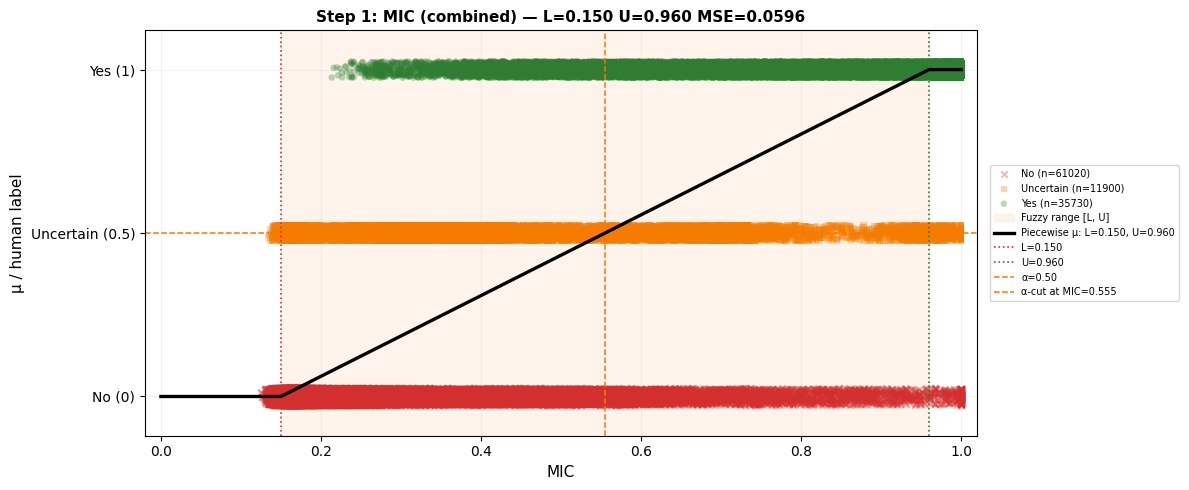

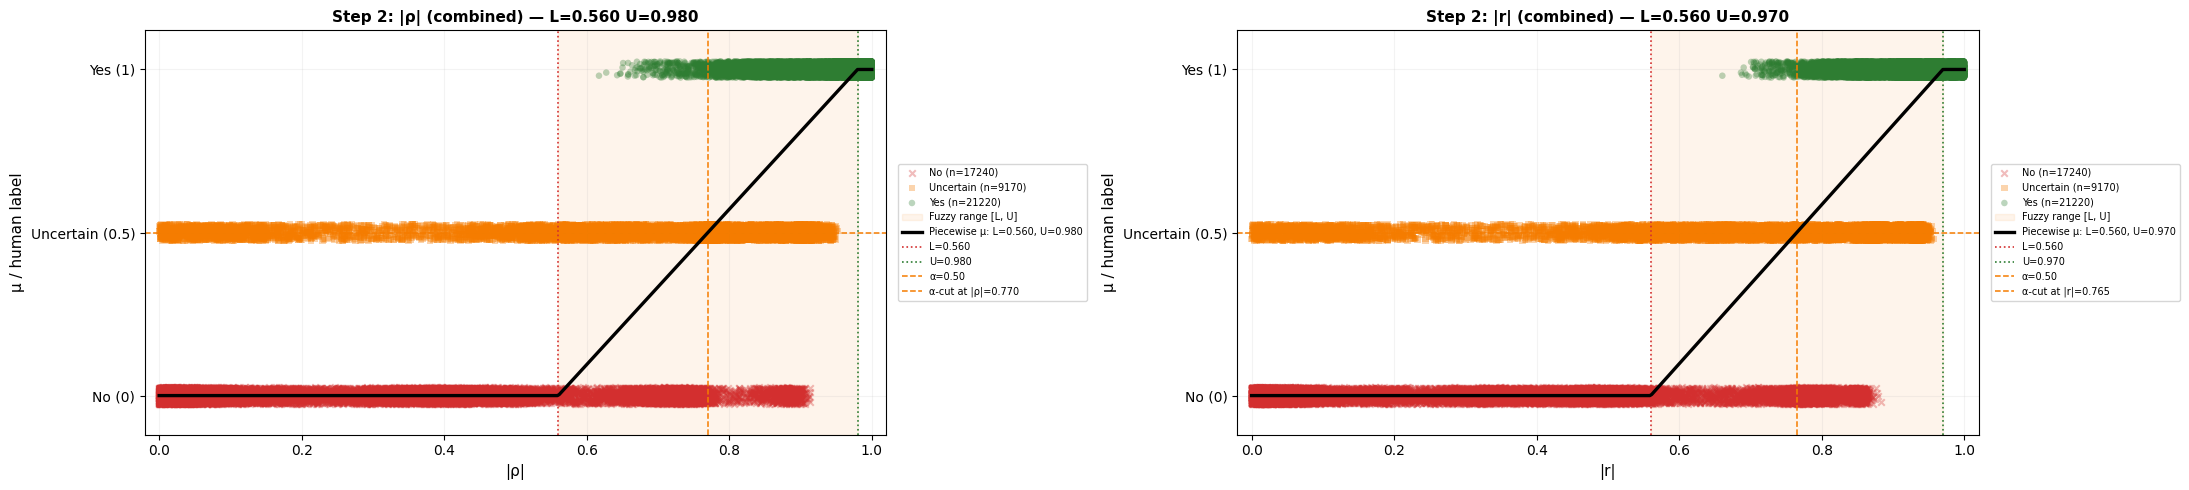

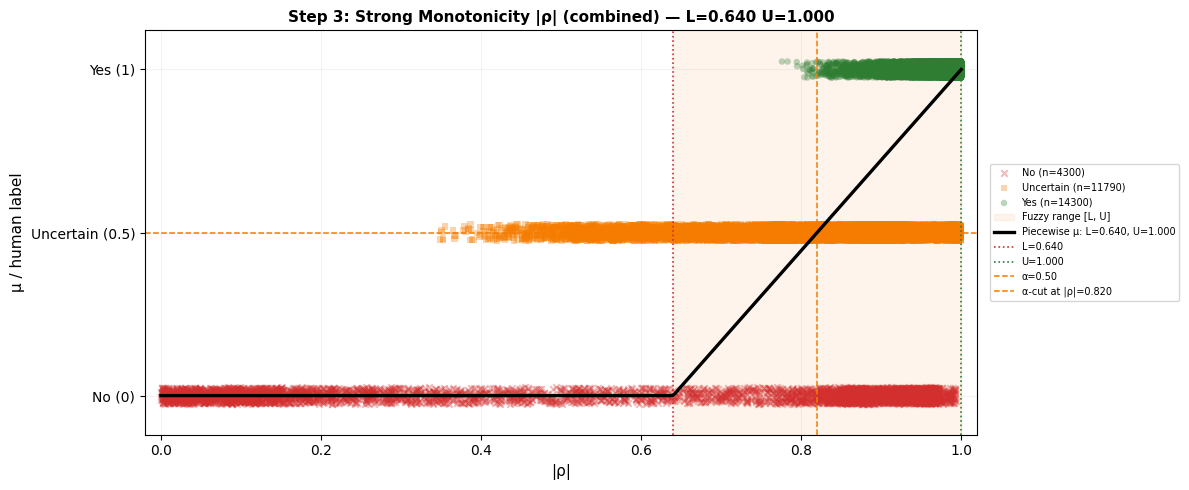

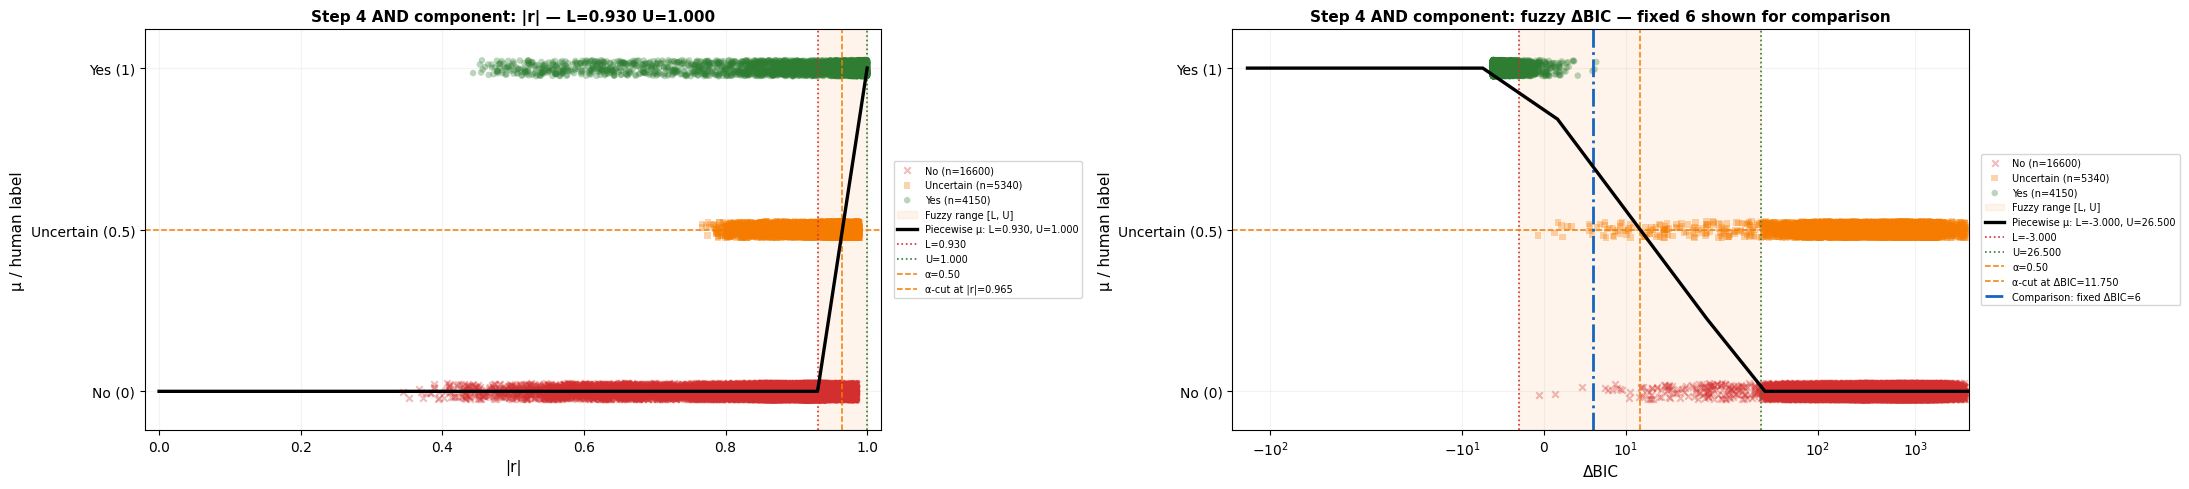

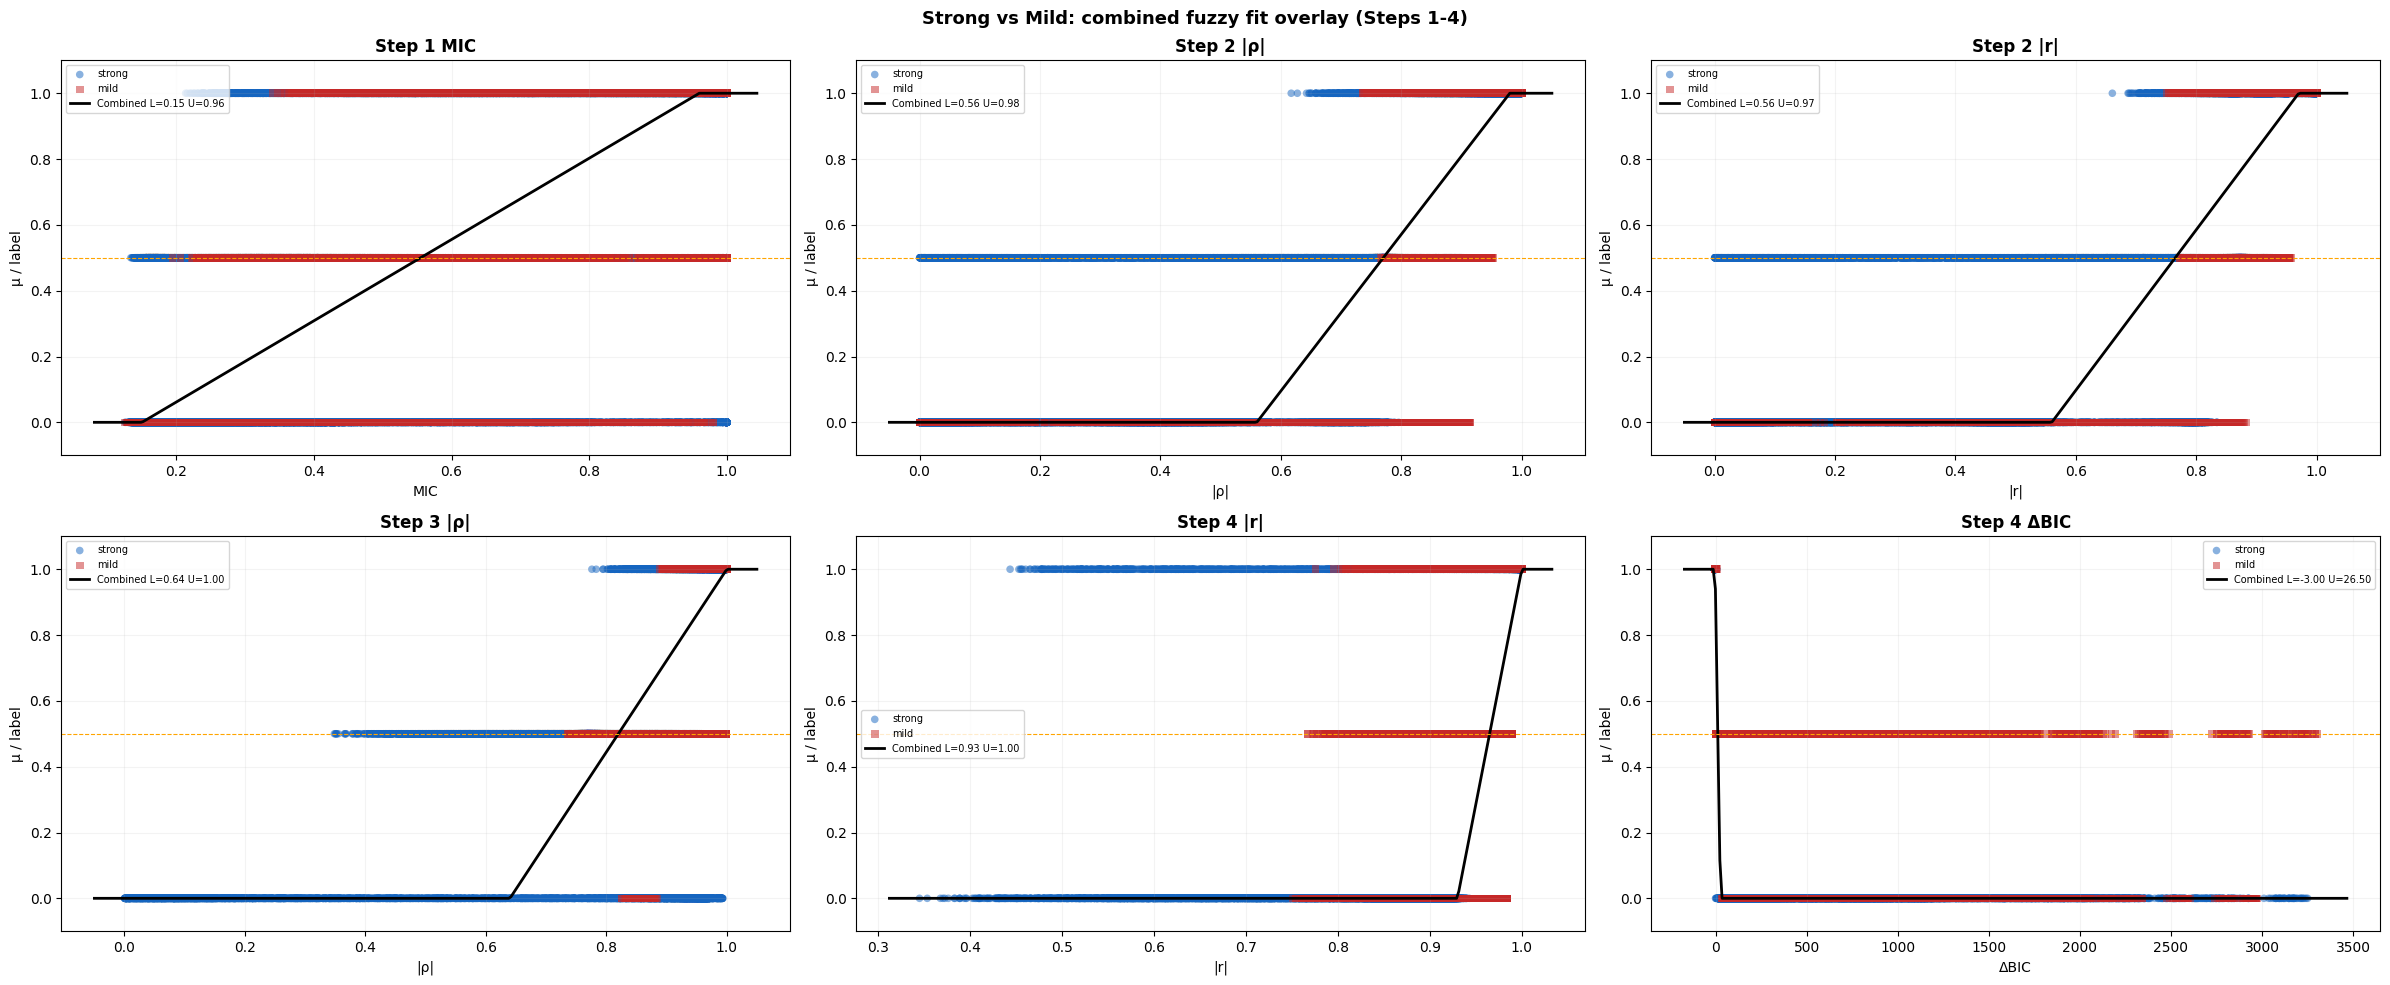

In [7]:
# ══════════════════════════════════════════════════════
#  Calibrated gate plots — combined training data (Steps 1-4)
# ══════════════════════════════════════════════════════
import matplotlib.pyplot as plt

# ── Step 1: MIC ──
fig, ax = plt.subplots(figsize=(12, 5))
r = results['step1_mic']
plot_calibrated_gate(ax,
    train['s1_mic']['indicator'].values, train['s1_mic']['label'].values,
    r['L'], r['U'], 'MIC',
    f'Step 1: MIC (combined) — L={r["L"]:.3f} U={r["U"]:.3f} MSE={r["mse"]:.4f}',
    alpha=ALPHA, increasing=True)
plt.tight_layout()
plt.show()

# ── Step 2: |ρ| and |r| ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))
r = results['step2_rho']
plot_calibrated_gate(ax1,
    train['s2_rho']['indicator'].values, train['s2_rho']['label'].values,
    r['L'], r['U'], '|ρ|',
    f'Step 2: |ρ| (combined) — L={r["L"]:.3f} U={r["U"]:.3f}',
    alpha=ALPHA, increasing=True)
r = results['step2_r']
plot_calibrated_gate(ax2,
    train['s2_r']['indicator'].values, train['s2_r']['label'].values,
    r['L'], r['U'], '|r|',
    f'Step 2: |r| (combined) — L={r["L"]:.3f} U={r["U"]:.3f}',
    alpha=ALPHA, increasing=True)
plt.tight_layout()
plt.show()

# ── Step 3: |ρ| ──
fig, ax = plt.subplots(figsize=(12, 5))
r = results['step3_rho']
plot_calibrated_gate(ax,
    train['s3_rho']['indicator'].values, train['s3_rho']['label'].values,
    r['L'], r['U'], '|ρ|',
    f'Step 3: Strong Monotonicity |ρ| (combined) — L={r["L"]:.3f} U={r["U"]:.3f}',
    alpha=ALPHA, increasing=True)
plt.tight_layout()
plt.show()

# ── Step 4: operational AND gate = fuzzy |r| AND fuzzy linear-model support ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))
r = results['step4_r']
plot_calibrated_gate(ax1,
    train['s4_r']['indicator'].values, train['s4_r']['label'].values,
    r['L'], r['U'], '|r|',
    f'Step 4 AND component: |r| — L={r["L"]:.3f} U={r["U"]:.3f}',
    alpha=ALPHA, increasing=True)
r = results['step4_bic']
plot_calibrated_gate(ax2,
    train['s4_bic']['indicator'].values, train['s4_bic']['label'].values,
    r['L'], r['U'], 'ΔBIC',
    f'Step 4 AND component: fuzzy ΔBIC — fixed 6 shown for comparison',
    alpha=ALPHA, increasing=False)
ax2.axvline(STEP4_BIC_THRESHOLD, color='#1565C0', ls='-.', lw=2.0,
            label=f'Comparison: fixed ΔBIC={STEP4_BIC_THRESHOLD:g}')
ax2.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.01, 0.5))
_lt = max(abs(r['U']), 1.0)
ax2.set_xscale('symlog', linthresh=_lt, linscale=2.0)
plt.tight_layout()
plt.show()

# ── Per-variant overlay: show strong vs mild on same axes ──
fig, axes = plt.subplots(2, 3, figsize=(24, 10))
gate_keys = [
    ('s1_mic',  'step1_mic',  'MIC',  'Step 1 MIC',  True),
    ('s2_rho',  'step2_rho',  '|ρ|',  'Step 2 |ρ|',  True),
    ('s2_r',    'step2_r',    '|r|',  'Step 2 |r|',  True),
    ('s3_rho',  'step3_rho',  '|ρ|',  'Step 3 |ρ|',  True),
    ('s4_r',    'step4_r',    '|r|',  'Step 4 |r|',  True),
    ('s4_bic',  'step4_bic',  'ΔBIC', 'Step 4 ΔBIC', False),
]
colors_v = {'strong': '#1565C0', 'mild': '#C62828'}
for idx, (tkey, rkey, xlab, title, increasing) in enumerate(gate_keys):
    ax = axes.flat[idx]
    r = results[rkey]
    t = train[tkey]

    for vname, color in colors_v.items():
        sub = t[t['variant'] == vname]
        marker = 'o' if vname == 'strong' else 's'
        ax.scatter(sub['indicator'], sub['label'],
                   c=color, marker=marker, s=30, alpha=0.5,
                   label=vname, edgecolors='none')

    lo, hi = t['indicator'].min(), t['indicator'].max()
    pad = 0.05 * max(hi - lo, 0.01)
    grid = np.linspace(lo - pad, hi + pad, 300)
    if increasing:
        mu = np.clip((grid - r['L']) / (r['U'] - r['L']), 0, 1)
    else:
        mu = 1.0 - np.clip((grid - r['L']) / (r['U'] - r['L']), 0, 1)
    ax.plot(grid, mu, 'k-', lw=2, label=f'Combined L={r["L"]:.2f} U={r["U"]:.2f}')
    ax.axhline(ALPHA, color='orange', ls='--', lw=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlab)
    ax.set_ylabel('μ / label')
    ax.set_ylim(-0.1, 1.1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.15)

plt.suptitle('Strong vs Mild: combined fuzzy fit overlay (Steps 1-4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ══════════════════════════════════════════════════════
#  Comparison: combined vs individual fits (Steps 1-4)
# ══════════════════════════════════════════════════════

old = {}
for tag, fname in [('strong', 'fuzzy_params.json'), ('mild', 'fuzzy_params_mild.json')]:
    p = OUT_DIR / fname
    if p.exists():
        with open(p) as f:
            old[tag] = json_mod.load(f)
        print(f'Loaded {tag} params from {fname}')
    else:
        print(f'{fname} not found — skip {tag} comparison')

gates = [
    ('Step 1 MIC',      'step1_mic',      'step1_mic'),
    ('Step 2 |ρ|',      'step2_rho',      'step2_rho'),
    ('Step 2 |r|',      'step2_r',        'step2_r'),
    ('Step 3 |ρ|',      'step3_rho',      'step3_rho'),
    ('Step 4 |r|',      'step4_r',        'step4_r'),
    ('Step 4 ΔBIC',     'step4_bic',      'step4_delta_bic'),
]

def get_nested(d, path):
    for key in path.split('.'):
        if key not in d: return None
        d = d[key]
    return d

rows = []
for label, res_key, old_key in gates:
    r = results[res_key]
    row = {'Gate': label,
           'Comb_L': round(r['L'], 3),
           'Comb_U': round(r['U'], 3),
           'Comb_MSE': round(r['mse'], 4)}
    for tag in ['strong', 'mild']:
        if tag in old:
            o = get_nested(old[tag], old_key)
            if o is not None:
                L_key = 'L_D' if 'L_D' in o else 'L'
                U_key = 'U_D' if 'U_D' in o else 'U'
                row[f'{tag}_L'] = round(o[L_key], 3)
                row[f'{tag}_U'] = round(o[U_key], 3)
                row[f'{tag}_MSE'] = round(o.get('mse', 0), 4)
    rows.append(row)

comp = pd.DataFrame(rows).set_index('Gate')
display(comp)
print('\n(Step 5 curvature is deterministic — no L/U comparison needed)')

Loaded strong params from fuzzy_params.json
fuzzy_params_mild.json not found — skip mild comparison


,Comb_L,Comb_U,Comb_MSE,strong_L,strong_U,strong_MSE
Gate,,,,,,
Step 1 MIC,0.15,0.96,0.0596,0.18,0.88,0.0588
Step 2 |ρ|,0.56,0.98,0.0488,0.69,0.99,0.0516
Step 2 |r|,0.56,0.97,0.0604,0.70,0.99,0.0594
Step 3 |ρ|,0.64,1.00,0.0772,0.86,0.99,0.0544
Step 4 |r|,0.93,1.00,0.1078,0.92,0.99,0.1496
Step 4 ΔBIC,-3.00,26.50,0.0509,0.00,12.00,0.1651



(Step 5 curvature is deterministic — no L/U comparison needed)


In [9]:
# ══════════════════════════════════════════════════════
#  Combined per-step success tables (both variants merged)
#  Step 5: deterministic f″ pattern classification
#  Two entry paths to Step 5: S4 non-linear + S3 failure
# ══════════════════════════════════════════════════════

all_eval = []
all_final = []

for vname in ['strong', 'mild']:
    v = variants[vname]
    ann = ANNOT[vname]
    curv_class = ann['CURVATURE_FAMILY_CLASS']

    ALL_FIDS = sorted(v['family_id'].unique())

    expected_s1_yes = set(ALL_FIDS) - set(ann['NO_GLOBAL']) - {'Null'}
    expected_s2_yes = set(ann['SIMPLE_FAM'] + ann['UNCERTAIN_S2'])
    expected_s4_line = set(ann['LINEAR_FAM'])
    expected_s4_nonline = set(ann['NONLINEAR_FAM'])

    mic_vals = v['MIC'].values
    mu_s1 = fuzzy_mu(mic_vals, results['step1_mic']['L'], results['step1_mic']['U'])
    pred_s1_pass = mu_s1 >= ALPHA

    rho_vals = v['abs_rho'].values
    r_vals   = v['abs_r'].values
    mu_s2_rho = fuzzy_mu(rho_vals, results['step2_rho']['L'], results['step2_rho']['U'])
    mu_s2_r   = fuzzy_mu(r_vals, results['step2_r']['L'], results['step2_r']['U'])
    mu_s2 = fuzzy_and(mu_s2_rho, mu_s2_r)
    pred_s2_pass = pred_s1_pass & (mu_s2 >= ALPHA)

    mu_s3 = fuzzy_mu(rho_vals, results['step3_rho']['L'], results['step3_rho']['U'])
    pred_s3_pass = pred_s2_pass & (mu_s3 >= ALPHA)

    mu_s4_r = fuzzy_mu(r_vals, results['step4_r']['L'], results['step4_r']['U'])
    bic_vals = v['delta_bic'].values
    mu_s4_bic = 1.0 - fuzzy_mu(bic_vals, results['step4_bic']['L'], results['step4_bic']['U'])
    # AND gate: both |r| membership and linear-model (ΔBIC) membership must pass.
    mu_s4_line = fuzzy_and(mu_s4_r, mu_s4_bic)
    pred_s4_line = pred_s3_pass & (mu_s4_line >= ALPHA)
    pred_s4_nonline = pred_s3_pass & ~pred_s4_line

    # Step 5: TWO entry paths
    # Path A: Step 4 non-linear
    # Path B: Step 3 failure (entered S3 but didn't pass fuzzy gate)
    s3_fams = set(ann['STRONG_MONO'] + ann['UNCERTAIN_MONO'] + ann['WEAK_MONO'])
    entered_s3 = pred_s2_pass & v['family_id'].isin(s3_fams)
    failed_s3 = entered_s3 & ~pred_s3_pass

    # Deterministic f″ classification: positive → Convex, negative → Concave,
    # meaningful interior sign change → Inflected, otherwise → Uncertain.
    pred_s5 = pd.Series('', index=v.index)
    s5_enter = (
        (pred_s4_nonline | failed_s3)
        & v['family_id'].isin(set(curv_class.keys()))
        & v['curvature_type'].ne('')
    )
    pred_s5.loc[s5_enter] = v.loc[s5_enter, 'curvature_type']

    eval_df = v[['case_id', 'family_id']].copy()
    eval_df['variant'] = vname
    eval_df['expected_s1'] = eval_df['family_id'].isin(expected_s1_yes)
    eval_df['correct_s1'] = pred_s1_pass == eval_df['expected_s1'].values

    eval_df['enter_s2'] = eval_df['correct_s1'] & eval_df['expected_s1'] & pred_s1_pass
    eval_df['expected_s2'] = eval_df['family_id'].isin(expected_s2_yes)
    eval_df['correct_s2'] = eval_df['enter_s2'] & (pred_s2_pass == eval_df['expected_s2'].values)

    eval_df['enter_s3'] = eval_df['correct_s2'] & eval_df['expected_s2'] & pred_s2_pass
    # Step 3 truth is SNR-specific: F15/F16 are uncertain/pass only at SNR >= 10.
    eval_df['expected_s3'] = v['label_s3'].fillna(0).to_numpy() > 0
    eval_df['correct_s3'] = eval_df['enter_s3'] & (pred_s3_pass == eval_df['expected_s3'].values)

    eval_df['enter_s4'] = eval_df['correct_s3'] & eval_df['expected_s3'] & pred_s3_pass
    eval_df['expected_s4_line'] = eval_df['family_id'].isin(expected_s4_line)
    eval_df['correct_s4'] = eval_df['enter_s4'] & (pred_s4_line == eval_df['expected_s4_line'].values)

    # Step 5: enter via S4 nonlinear OR S3 failure, must be in curvature class
    eval_df['enter_s5'] = (
        eval_df['family_id'].isin(set(curv_class.keys()))
        & (s5_enter.values)
    )
    eval_df['pred_s5'] = pred_s5
    eval_df['expected_s5'] = eval_df['family_id'].map(curv_class)
    eval_df['correct_s5'] = eval_df['enter_s5'] & (pred_s5 == eval_df['expected_s5'].values)
    eval_df['s5_entry_path'] = np.select(
        [pred_s4_nonline, failed_s3],
        ['S4 non-line', 'S3 non-strong'],
        default='',
    )
    eval_df['enter_s1'] = True

    all_eval.append(eval_df)

    # Final prediction
    final = v[['case_id', 'family_id']].copy()
    final['variant'] = vname
    final['prediction'] = 'Unresolved'
    final.loc[~pred_s1_pass, 'prediction'] = 'No global'
    final.loc[pred_s1_pass & ~pred_s2_pass, 'prediction'] = 'Complex'
    final.loc[pred_s2_pass & ~pred_s3_pass & ~(failed_s3 & s5_enter), 'prediction'] = 'Weak mono'
    final.loc[pred_s4_line, 'prediction'] = 'Line'
    s5_has = pred_s5 != ''
    final.loc[s5_has, 'prediction'] = pred_s5[s5_has]

    EXPECTED_FINAL = {
        **{fid: 'No global' for fid in list(ann['NO_GLOBAL']) + ['Null']},
        **{fid: 'Complex' for fid in ann['COMPLEX_FAM']},
        **{fid: 'Line' for fid in ann['LINEAR_FAM']},
        **curv_class,
    }
    final['expected'] = final['family_id'].map(EXPECTED_FINAL)
    final['correct'] = final['prediction'] == final['expected']
    # Denominator for the post-global rate: every case predicted as Global at Step 1.
    final['passed_global'] = pred_s1_pass
    all_final.append(final)

# ── Stack both variants ──
eval_all = pd.concat(all_eval, ignore_index=True)
final_all = pd.concat(all_final, ignore_index=True)

# ── Build per-step data used by the compact reports below ──
step_tables = []

for step in range(1, 6):
    enter_col = f'enter_s{step}'
    correct_col = f'correct_s{step}'
    sub = eval_all[eval_all[enter_col]]
    if len(sub) == 0:
        print(f'Step {step}: no rows entered')
        continue

    group_cols = ['variant', 'family_id']
    if step == 5:
        group_cols.append('s5_entry_path')
    tbl = sub.groupby(group_cols).agg(
        entered=(enter_col, 'sum'),
        correct=(correct_col, 'sum'),
    ).reset_index()
    tbl['rate'] = np.where(tbl['entered'] > 0, tbl['correct'] / tbl['entered'], np.nan)

    if step == 5:
        tbl['expected'] = tbl.apply(
            lambda r: ANNOT[r['variant']]['CURVATURE_FAMILY_CLASS'].get(r['family_id'], '?'), axis=1)
    elif step == 4:
        def s4_cat(r):
            ann = ANNOT[r['variant']]
            if r['family_id'] in ann['LINEAR_FAM']: return 'Line'
            if r['family_id'] in ann.get('UNCERTAIN_LINEAR', []): return 'Uncertain'
            if r['family_id'] in ann['NONLINEAR_FAM']: return 'Non-line'
            return '?'
        tbl['expected'] = tbl.apply(s4_cat, axis=1)
    elif step == 3:
        def s3_cat(r):
            ann = ANNOT[r['variant']]
            if r['family_id'] in ann['STRONG_MONO']: return 'Strong'
            if r['family_id'] in ann['UNCERTAIN_MONO']: return 'Uncertain'
            if r['family_id'] in ann['WEAK_MONO']: return 'Weak'
            return '?'
        tbl['expected'] = tbl.apply(s3_cat, axis=1)
    elif step == 2:
        def s2_cat(r):
            ann = ANNOT[r['variant']]
            if r['family_id'] in ann['SIMPLE_FAM']: return 'Simple'
            if r['family_id'] in ann['UNCERTAIN_S2']: return 'Uncertain'
            if r['family_id'] in ann['COMPLEX_FAM']: return 'Complex'
            return '?'
        tbl['expected'] = tbl.apply(s2_cat, axis=1)
    else:
        def s1_cat(r):
            ann = ANNOT[r['variant']]
            if r['family_id'] in ann['NO_GLOBAL'] or r['family_id'] == 'Null': return 'No global'
            return 'Global'
        tbl['expected'] = tbl.apply(s1_cat, axis=1)

    tbl = tbl.sort_values(['variant', 'family_id'])
    total_entered = int(tbl['entered'].sum())
    total_correct = int(tbl['correct'].sum())
    overall_rate = total_correct / total_entered if total_entered > 0 else 0

    tbl['step'] = step
    step_tables.append(tbl.copy())

# ── Compact pipeline tables: Mild and Strong side by side, then combined ──
from IPython.display import HTML
family_name_map = (cases[['family_id', 'family_name']].drop_duplicates('family_id')
                   .set_index('family_id')['family_name'].to_dict())

def _count_rate(correct, entered):
    if entered == 0:
        return '—'
    return f'{int(correct)}/{int(entered)} ({correct / entered:.1%})'

step_detail = pd.concat(step_tables, ignore_index=True)

def _step_variant_table(step, variant):
    if step <= 4:
        # Shared Null cases appear in each diagnostic variant table but only once in Combined.
        sub = gate_case_eval[(gate_case_eval['step'] == step) &
            gate_case_eval['variant'].isin([variant, 'shared_null'])].copy()
        sub = sub.groupby('family_id', as_index=False).agg(
            cases=('case_id', 'size'), correct=('correct', 'sum'))
        sub['Family'] = sub['family_id'].map(
            lambda fid: f'{fid} {family_name_map.get(fid, "")}'.strip())
        sub['Correct / cases'] = sub.apply(
            lambda r: _count_rate(r['correct'], r['cases']), axis=1)
        out = sub[['Family', 'Correct / cases']].set_index('Family')
        out.loc['Overall', 'Correct / cases'] = _count_rate(
            sub['correct'].sum(), sub['cases'].sum())
        return out

    sub = step_detail[(step_detail['step'] == 5) &
                      (step_detail['variant'] == variant)].copy()
    sub = sub.groupby(['family_id', 'expected'], as_index=False).agg(
        cases=('entered', 'sum'), correct=('correct', 'sum'))
    sub['Family'] = sub['family_id'].map(
        lambda fid: f'{fid} {family_name_map.get(fid, "")}'.strip())
    sub['Correct / cases'] = sub.apply(
        lambda r: _count_rate(r['correct'], r['cases']), axis=1)
    out = sub[['Family', 'expected', 'Correct / cases']].rename(
        columns={'expected': 'Expected'}).set_index('Family')
    out.loc['Overall'] = ['', _count_rate(sub['correct'].sum(), sub['cases'].sum())]
    return out

def _step_combined_table(step):
    if step <= 4:
        sub = gate_case_eval[gate_case_eval['step'] == step].groupby(
            'family_id', as_index=False).agg(
                cases=('case_id', 'size'), correct=('correct', 'sum'))
    else:
        sub = step_detail[step_detail['step'] == 5].groupby(
            'family_id', as_index=False).agg(
                cases=('entered', 'sum'), correct=('correct', 'sum'))
    sub['Family'] = sub['family_id'].map(
        lambda fid: f'{fid} {family_name_map.get(fid, "")}'.strip())
    sub['Correct / cases'] = sub.apply(
        lambda r: _count_rate(r['correct'], r['cases']), axis=1)
    out = sub[['Family', 'Correct / cases']].set_index('Family')
    out.loc['Overall', 'Correct / cases'] = _count_rate(
        sub['correct'].sum(), sub['cases'].sum())
    return out

def _side_by_side(left, right, left_title='Mild', right_title='Strong'):
    css = '''<style>
    .report-grid{display:grid;grid-template-columns:1fr 1fr;gap:18px;align-items:start}
    .report-grid>div{overflow-x:auto}.report-grid table,.combined-report table{font-family:monospace;font-size:11px;border-collapse:collapse;width:100%}
    .report-grid th,.report-grid td,.combined-report th,.combined-report td{padding:3px 6px;text-align:right;white-space:nowrap}
    .report-grid th:first-child,.report-grid td:first-child,.combined-report th:first-child,.combined-report td:first-child{text-align:left}
    </style>'''
    html = (css + '<div class="report-grid">'
            + f'<div><h3>{left_title}</h3>{left.to_html()}</div>'
            + f'<div><h3>{right_title}</h3>{right.to_html()}</div></div>')
    display(HTML(html))

for step in range(1, 6):
    display(HTML(f'<h2>Step {step} — Mild and Strong</h2>'))
    _side_by_side(_step_variant_table(step, 'mild'),
                  _step_variant_table(step, 'strong'))
    combined_step = _step_combined_table(step)
    display(HTML('<div class="combined-report">'
                 f'<h3>Step {step} — Combined</h3>'
                 + combined_step.to_html() + '</div>'))

# ── Combined Step 4 accuracy: calibrated fuzzy BIC vs fixed ΔBIC=6 ──
s4 = all_labeled_cases.loc[valid4].copy()
truth_s4 = s4['label_s4'].to_numpy(dtype=float) >= ALPHA
r_pass_s4 = fuzzy_mu(s4['abs_r'].to_numpy(),
                         results['step4_r']['L'], results['step4_r']['U']) >= ALPHA
bic_fuzzy_pass_s4 = (1.0 - fuzzy_mu(
    s4['delta_bic'].to_numpy(), results['step4_bic']['L'],
    results['step4_bic']['U'])) >= ALPHA
bic6_pass_s4 = s4['delta_bic'].to_numpy() <= STEP4_BIC_THRESHOLD
step4_methods = {
    'Calibrated AND: fuzzy |r| + fuzzy ΔBIC': r_pass_s4 & bic_fuzzy_pass_s4,
    'Fixed-6 AND: fuzzy |r| + ΔBIC≤6': r_pass_s4 & bic6_pass_s4,
}
step4_compare_rows = []
for method, pred in step4_methods.items():
    correct = int(np.sum(pred == truth_s4))
    step4_compare_rows.append({
        'Method': method, 'Cases': len(truth_s4), 'Correct': correct,
        'Accuracy': correct / len(truth_s4),
    })
step4_compare = pd.DataFrame(step4_compare_rows)
step4_compare['Accuracy'] = step4_compare['Accuracy'].map(lambda x: f'{x:.1%}')
display(HTML('<h2>Combined Step 4 accuracy: calibrated versus fixed ΔBIC=6</h2>'))
display(step4_compare.set_index('Method'))

# ── Final classification table ──
ftbl = final_all.dropna(subset=['expected']).groupby(['variant', 'family_id']).agg(
    n=('case_id', 'size'),
    correct=('correct', 'sum'),
    top_pred=('prediction', lambda s: s.value_counts().index[0]),
).reset_index()
ftbl['rate'] = ftbl['correct'] / ftbl['n']
ftbl['expected'] = ftbl.apply(
    lambda r: {
        **{fid: 'No global' for fid in list(ANNOT[r['variant']]['NO_GLOBAL']) + ['Null']},
        **{fid: 'Complex' for fid in ANNOT[r['variant']]['COMPLEX_FAM']},
        **{fid: 'Line' for fid in ANNOT[r['variant']]['LINEAR_FAM']},
        **ANNOT[r['variant']]['CURVATURE_FAMILY_CLASS'],
    }.get(r['family_id'], '?'), axis=1)
ftbl = ftbl.sort_values(['variant', 'family_id'])

def _final_variant_table(variant):
    sub = ftbl[ftbl['variant'] == variant].copy()
    sub['Family'] = sub['family_id'].map(
        lambda fid: f'{fid} {family_name_map.get(fid, "")}'.strip())
    sub['Correct / total'] = sub.apply(
        lambda r: _count_rate(r['correct'], r['n']), axis=1)
    out = sub[['Family', 'expected', 'top_pred', 'Correct / total']].rename(
        columns={'expected': 'Expected', 'top_pred': 'Top prediction'})
    return out.set_index('Family')

mild_final = _final_variant_table('mild')
strong_final = _final_variant_table('strong')
display(HTML('<h2>Final classification — Mild vs Strong</h2>'))
_side_by_side(mild_final, strong_final)

combined_final = final_all.dropna(subset=['expected']).groupby('family_id').agg(
    n=('case_id', 'size'), correct=('correct', 'sum')).reset_index()
combined_final['Family'] = combined_final['family_id'].map(
    lambda fid: f'{fid} {family_name_map.get(fid, "")}'.strip())
combined_final['Final correct'] = combined_final.apply(
    lambda r: _count_rate(r['correct'], r['n']), axis=1)
combined_final = combined_final[['Family', 'Final correct']].set_index('Family')
combined_final.loc['Overall', 'Final correct'] = _count_rate(
    final_all['correct'].sum(), final_all['expected'].notna().sum())
display(HTML('<div class="combined-report"><h2>Combined final classification</h2>'
             + combined_final.to_html() + '</div>'))

# ── End-to-end accuracy after the Global gate ──
# Denominator includes every case predicted Global, including Step-1 false positives.
post_global = final_all[final_all['passed_global'] & final_all['expected'].notna()].copy()
post_global_tbl = post_global.groupby('variant').agg(
    passed_global=('case_id', 'size'),
    final_correct=('correct', 'sum'),
).reset_index()
post_global_tbl['rate'] = post_global_tbl['final_correct'] / post_global_tbl['passed_global']
post_global_tbl = pd.concat([
    post_global_tbl,
    pd.DataFrame([{
        'variant': 'combined',
        'passed_global': len(post_global),
        'final_correct': int(post_global['correct'].sum()),
        'rate': float(post_global['correct'].mean()),
    }]),
], ignore_index=True)
post_global_display = post_global_tbl.copy()
post_global_display['Correct / passed Global'] = post_global_display.apply(
    lambda r: _count_rate(r['final_correct'], r['passed_global']), axis=1)
display(HTML('<h2>Post-global final accuracy</h2>'
             '<p>Denominator = all cases predicted Global at Step 1.</p>'))
pg_mild = post_global_display[post_global_display['variant'] == 'mild'][
    ['Correct / passed Global']].T
pg_strong = post_global_display[post_global_display['variant'] == 'strong'][
    ['Correct / passed Global']].T
pg_mild.columns = ['Result']; pg_strong.columns = ['Result']
_side_by_side(pg_mild, pg_strong)
pg_combined = post_global_display[post_global_display['variant'] == 'combined'][
    ['Correct / passed Global']].copy()
pg_combined.index = ['Combined']
display(HTML('<div class="combined-report"><h3>Combined</h3>'
             + pg_combined.to_html() + '</div>'))

,Correct / cases
Family,
F01 Linear positive,1995/2050 (97.3%)
F02 Linear negative,1984/2050 (96.8%)
F03 Power convex positive,2002/2050 (97.7%)
F04 Power convex negative,2012/2050 (98.1%)
F05 Power concave positive,2015/2050 (98.3%)
F06 Power concave negative,2009/2050 (98.0%)
F07 Saturation positive,2031/2050 (99.1%)
F08 Saturation negative,2034/2050 (99.2%)
F09 Log positive,2028/2050 (98.9%)


,Correct / cases
Family,
F01 Linear positive,3815/4100 (93.0%)
F02 Linear negative,3804/4100 (92.8%)
F03 Power convex positive,3730/4100 (91.0%)
F04 Power convex negative,3727/4100 (90.9%)
F05 Power concave positive,3752/4100 (91.5%)
F06 Power concave negative,3742/4100 (91.3%)
F07 Saturation positive,3523/4100 (85.9%)
F08 Saturation negative,3533/4100 (86.2%)
F09 Log positive,3761/4100 (91.7%)


,Correct / cases
Family,
F01 Linear positive,900/900 (100.0%)
F02 Linear negative,890/890 (100.0%)
F03 Power convex positive,888/890 (99.8%)
F04 Power convex negative,890/890 (100.0%)
F05 Power concave positive,890/890 (100.0%)
F06 Power concave negative,890/890 (100.0%)
F07 Saturation positive,877/890 (98.5%)
F08 Saturation negative,878/890 (98.7%)
F09 Log positive,890/890 (100.0%)


,Correct / cases
Family,
F01 Linear positive,1848/2080 (88.8%)
F02 Linear negative,1840/2070 (88.9%)
F03 Power convex positive,1649/2070 (79.7%)
F04 Power convex negative,1636/2070 (79.0%)
F05 Power concave positive,1841/2070 (88.9%)
F06 Power concave negative,1843/2070 (89.0%)
F07 Saturation positive,877/890 (98.5%)
F08 Saturation negative,878/890 (98.7%)
F09 Log positive,1837/2070 (88.7%)


,Correct / cases
Family,
F01 Linear positive,891/900 (99.0%)
F02 Linear negative,888/890 (99.8%)
F03 Power convex positive,860/890 (96.6%)
F04 Power convex negative,859/890 (96.5%)
F05 Power concave positive,879/890 (98.8%)
F06 Power concave negative,879/890 (98.8%)
F07 Saturation positive,811/890 (91.1%)
F08 Saturation negative,813/890 (91.3%)
F09 Log positive,849/890 (95.4%)


...

,Cases,Correct,Accuracy
Method,,,
Calibrated AND: fuzzy |r| + fuzzy ΔBIC,26090,19006,72.8%
Fixed-6 AND: fuzzy |r| + ΔBIC≤6,26090,19004,72.8%


,Expected,Top prediction,Correct / total
Family,,,
F01 Linear positive,Line,No global,600/2050 (29.3%)
F02 Linear negative,Line,No global,599/2050 (29.2%)
F03 Power convex positive,Convex,No global,903/2050 (44.0%)
F04 Power convex negative,Concave,No global,911/2050 (44.4%)
F05 Power concave positive,Concave,No global,82/2050 (4.0%)
F06 Power concave negative,Convex,No global,107/2050 (5.2%)
F07 Saturation positive,Concave,No global,659/2050 (32.1%)
F08 Saturation negative,Convex,No global,650/2050 (31.7%)
F09 Log positive,Concave,No global,42/2050 (2.0%)


,Final correct
Family,
F01 Linear positive,1203/4100 (29.3%)
F02 Linear negative,1203/4100 (29.3%)
F03 Power convex positive,933/4100 (22.8%)
F04 Power convex negative,933/4100 (22.8%)
F05 Power concave positive,82/4100 (2.0%)
F06 Power concave negative,107/4100 (2.6%)
F07 Saturation positive,2151/4100 (52.5%)
F08 Saturation negative,2149/4100 (52.4%)
F09 Log positive,42/4100 (1.0%)


,Result
Correct / passed Global,14696/21082 (69.7%)
,Result
Correct / passed Global,8361/18114 (46.2%)


,Correct / passed Global
Combined,23057/39196 (58.8%)


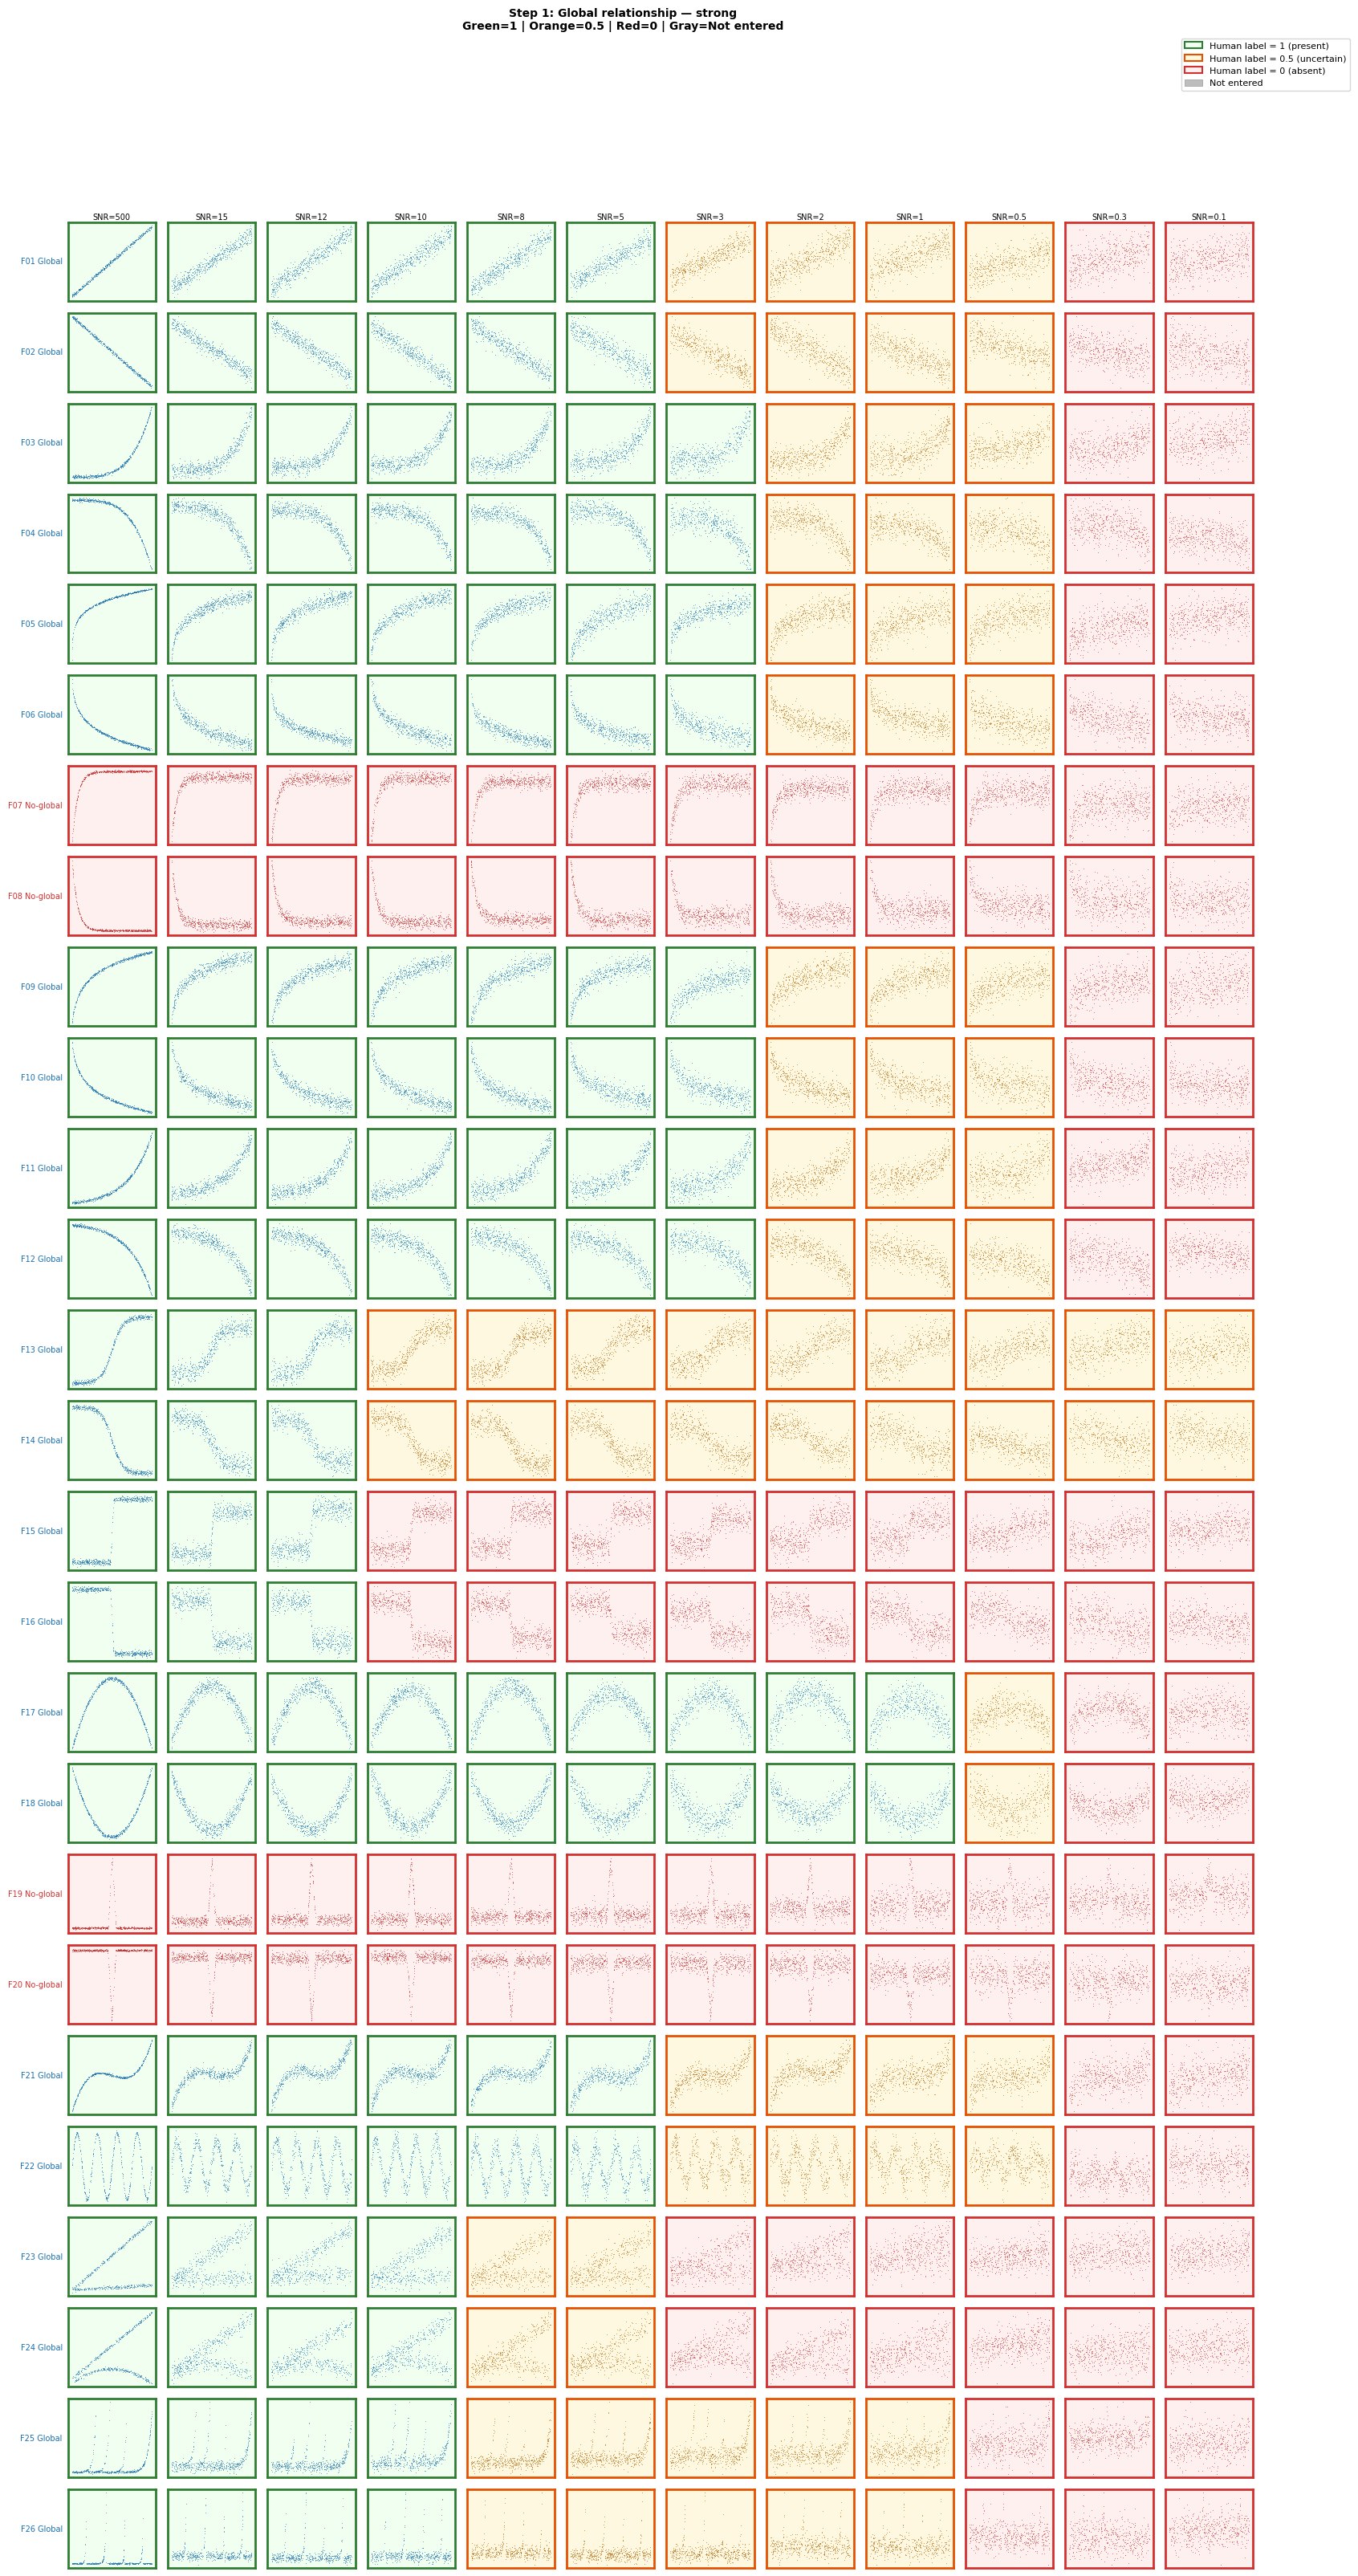

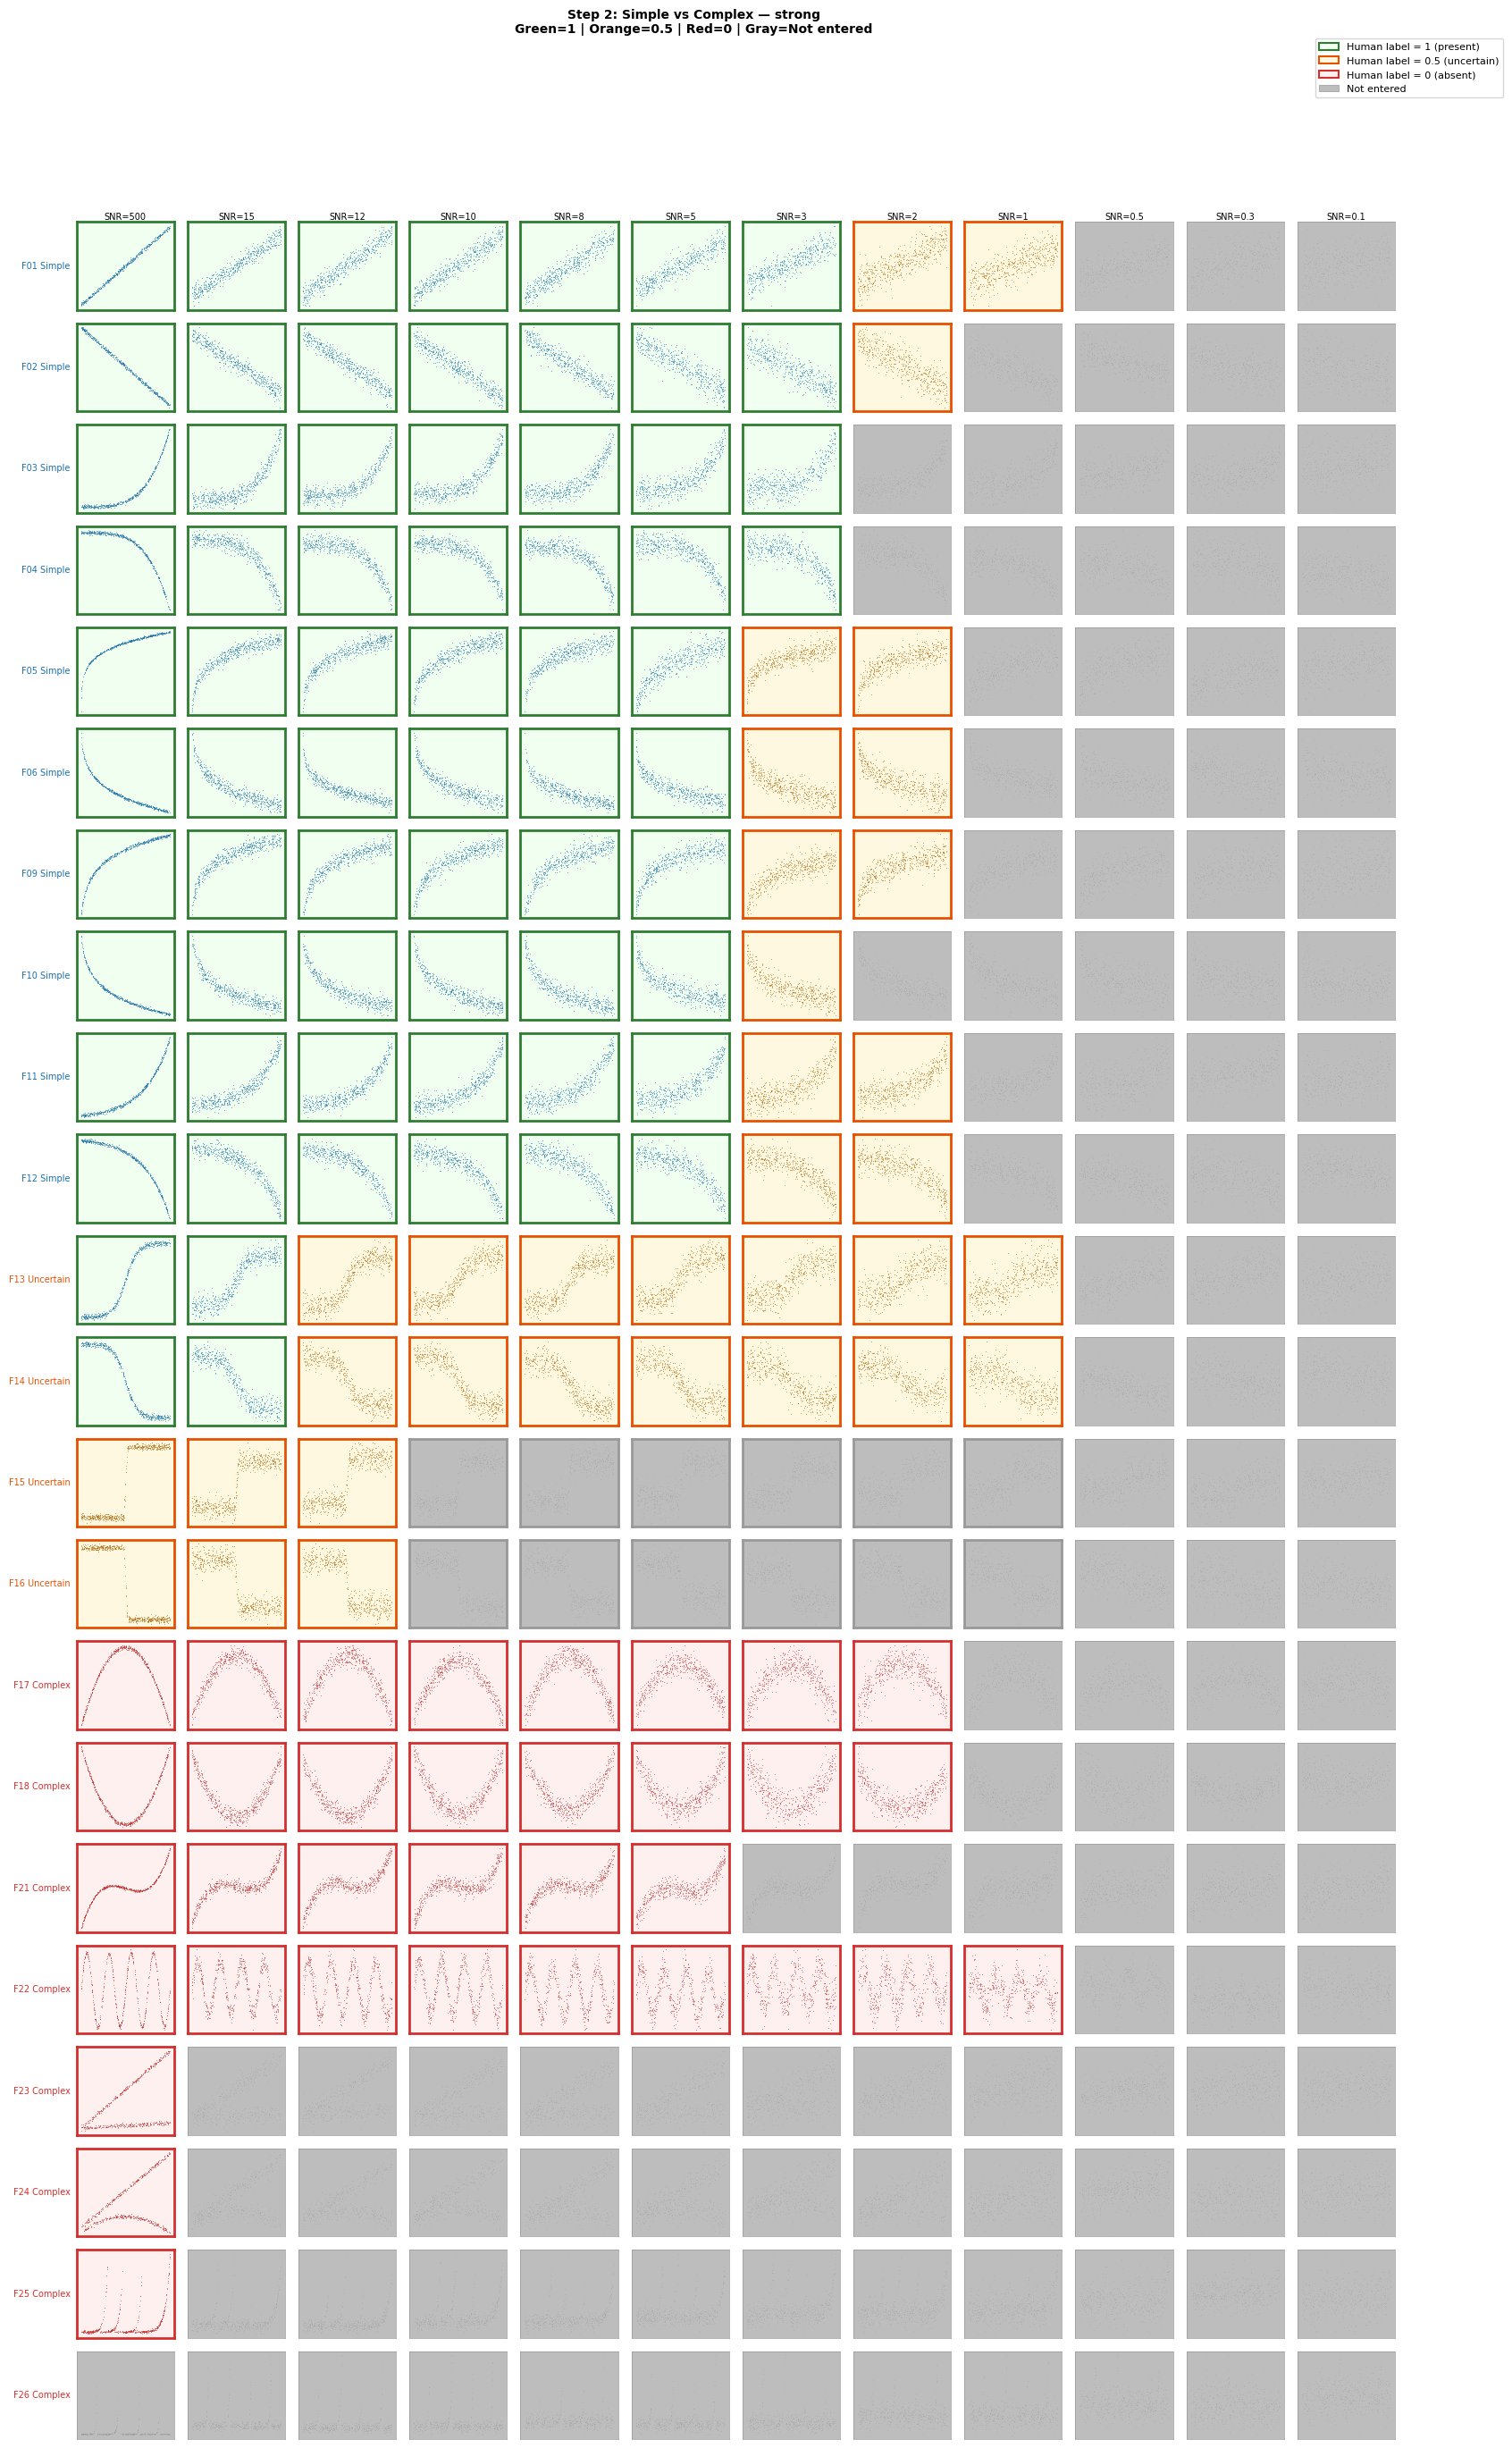

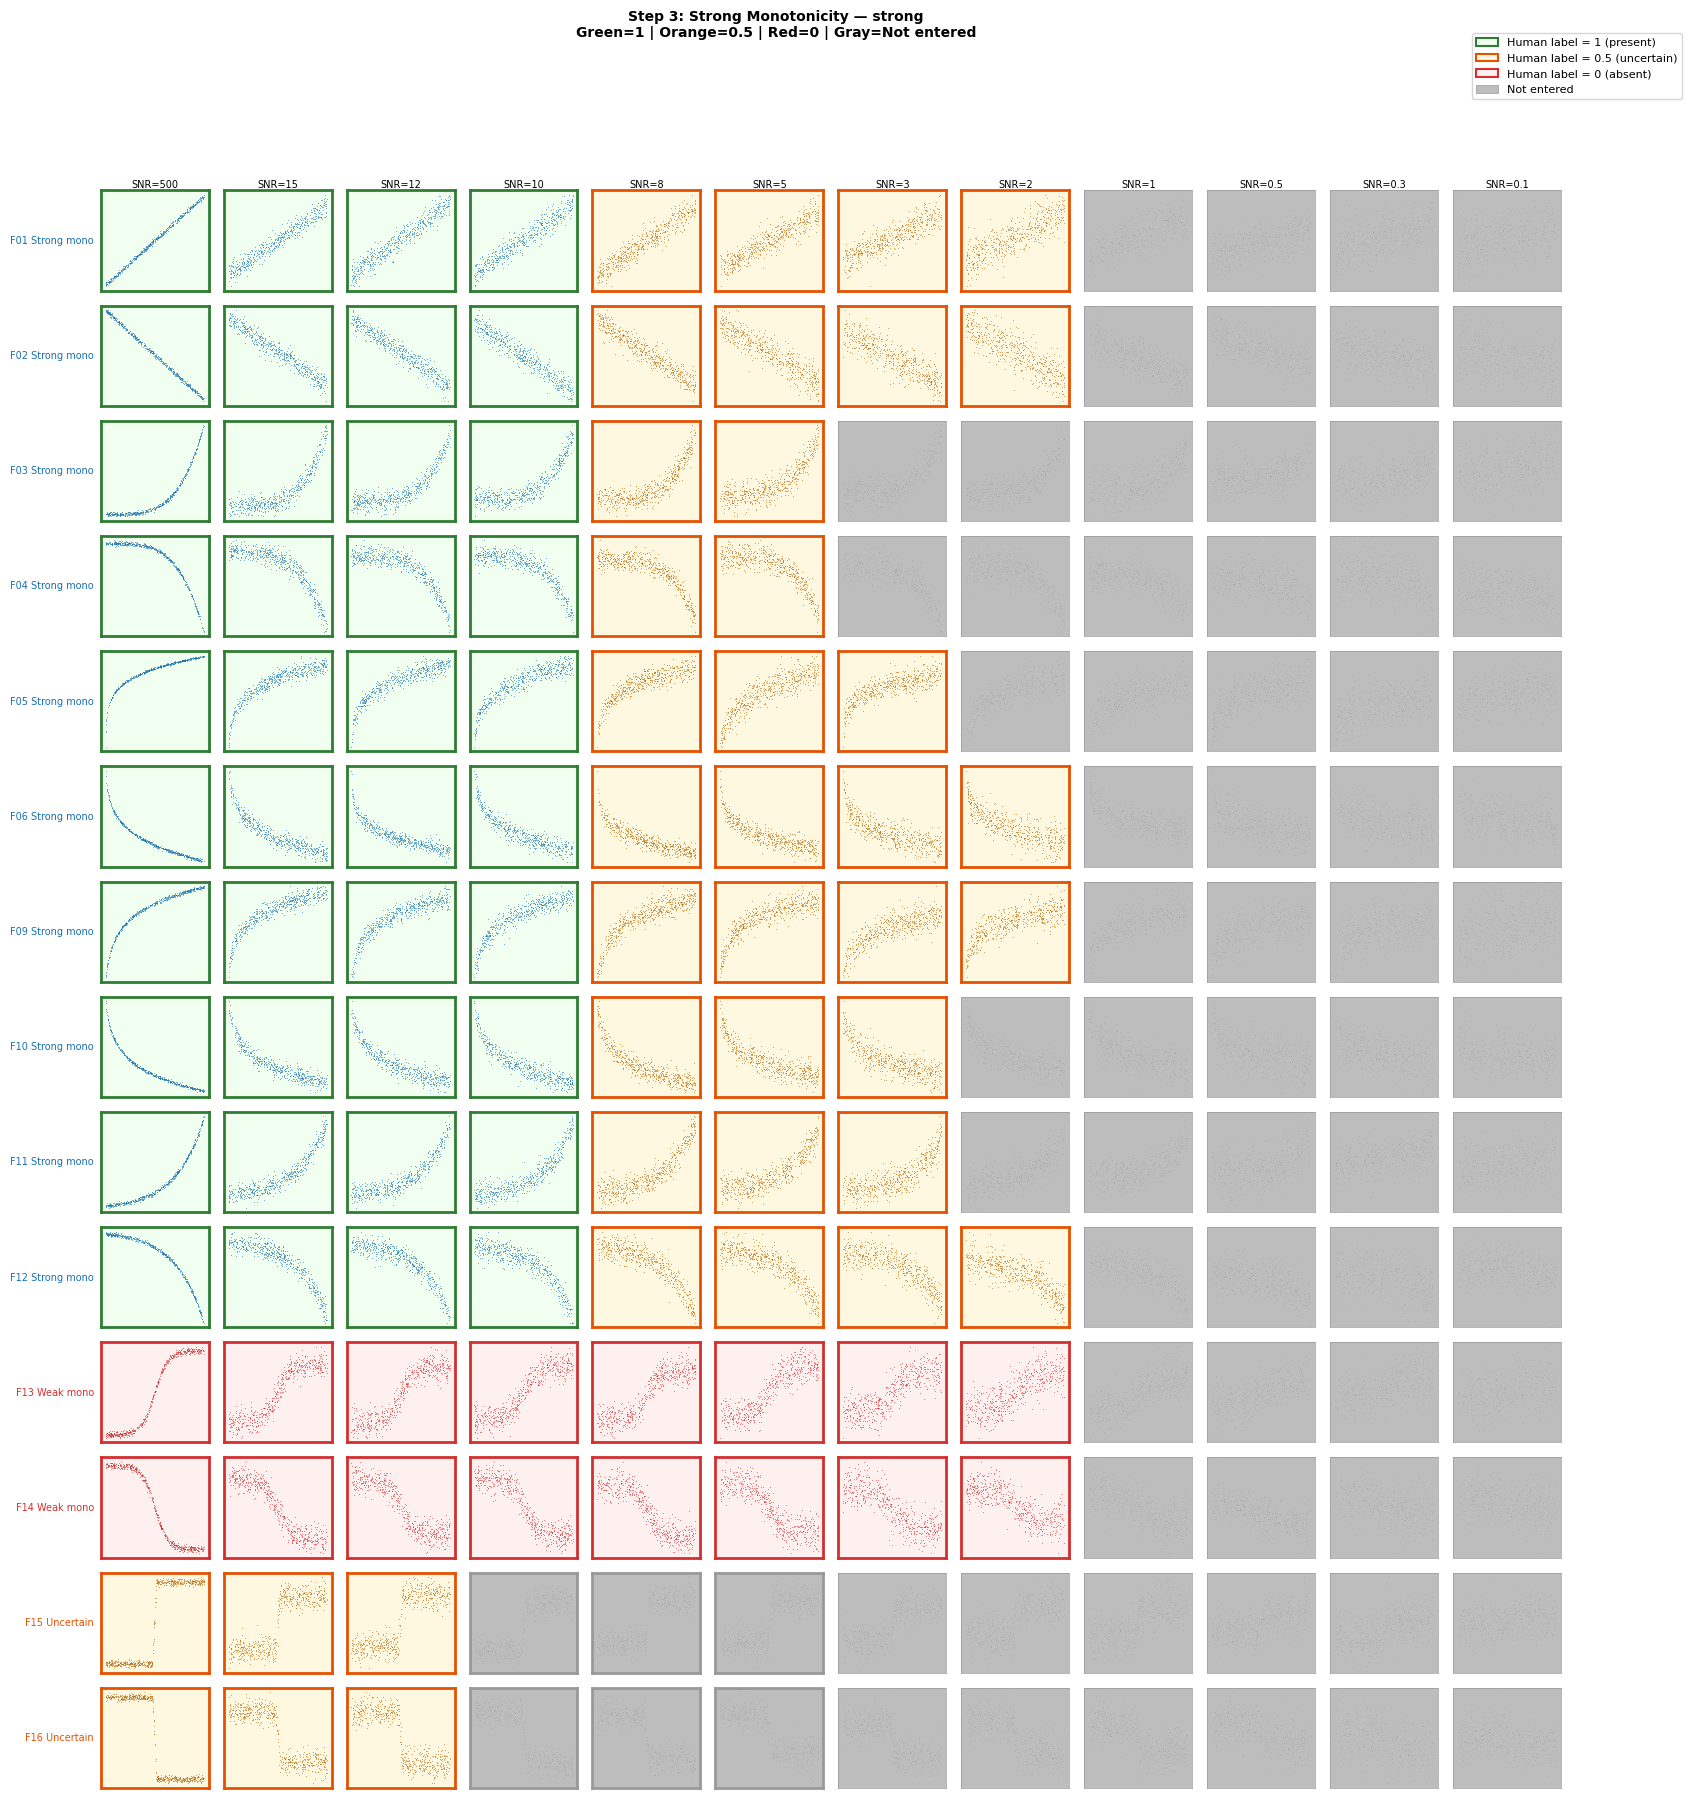

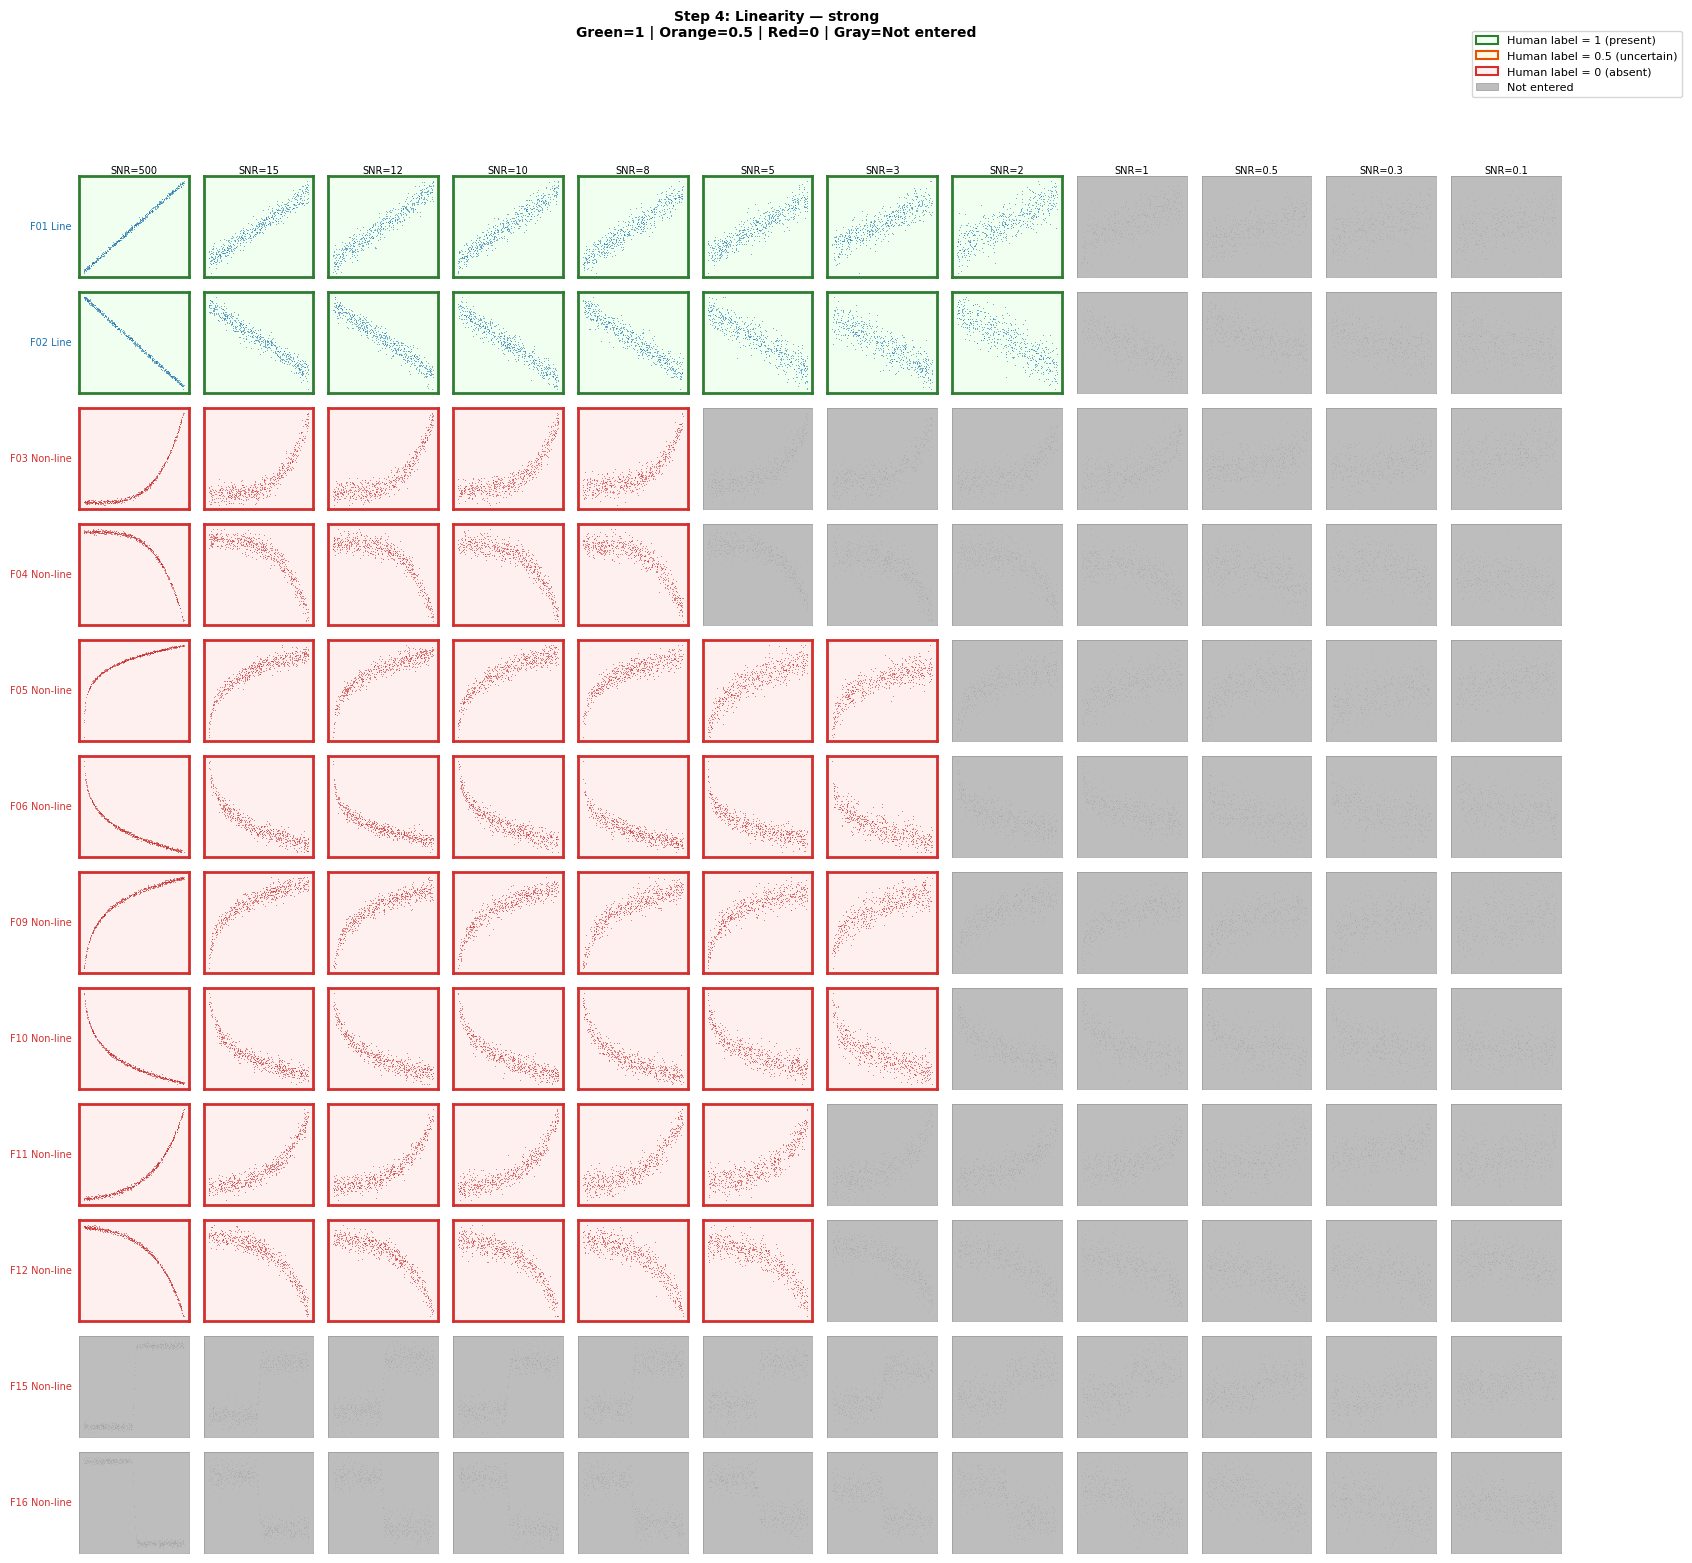

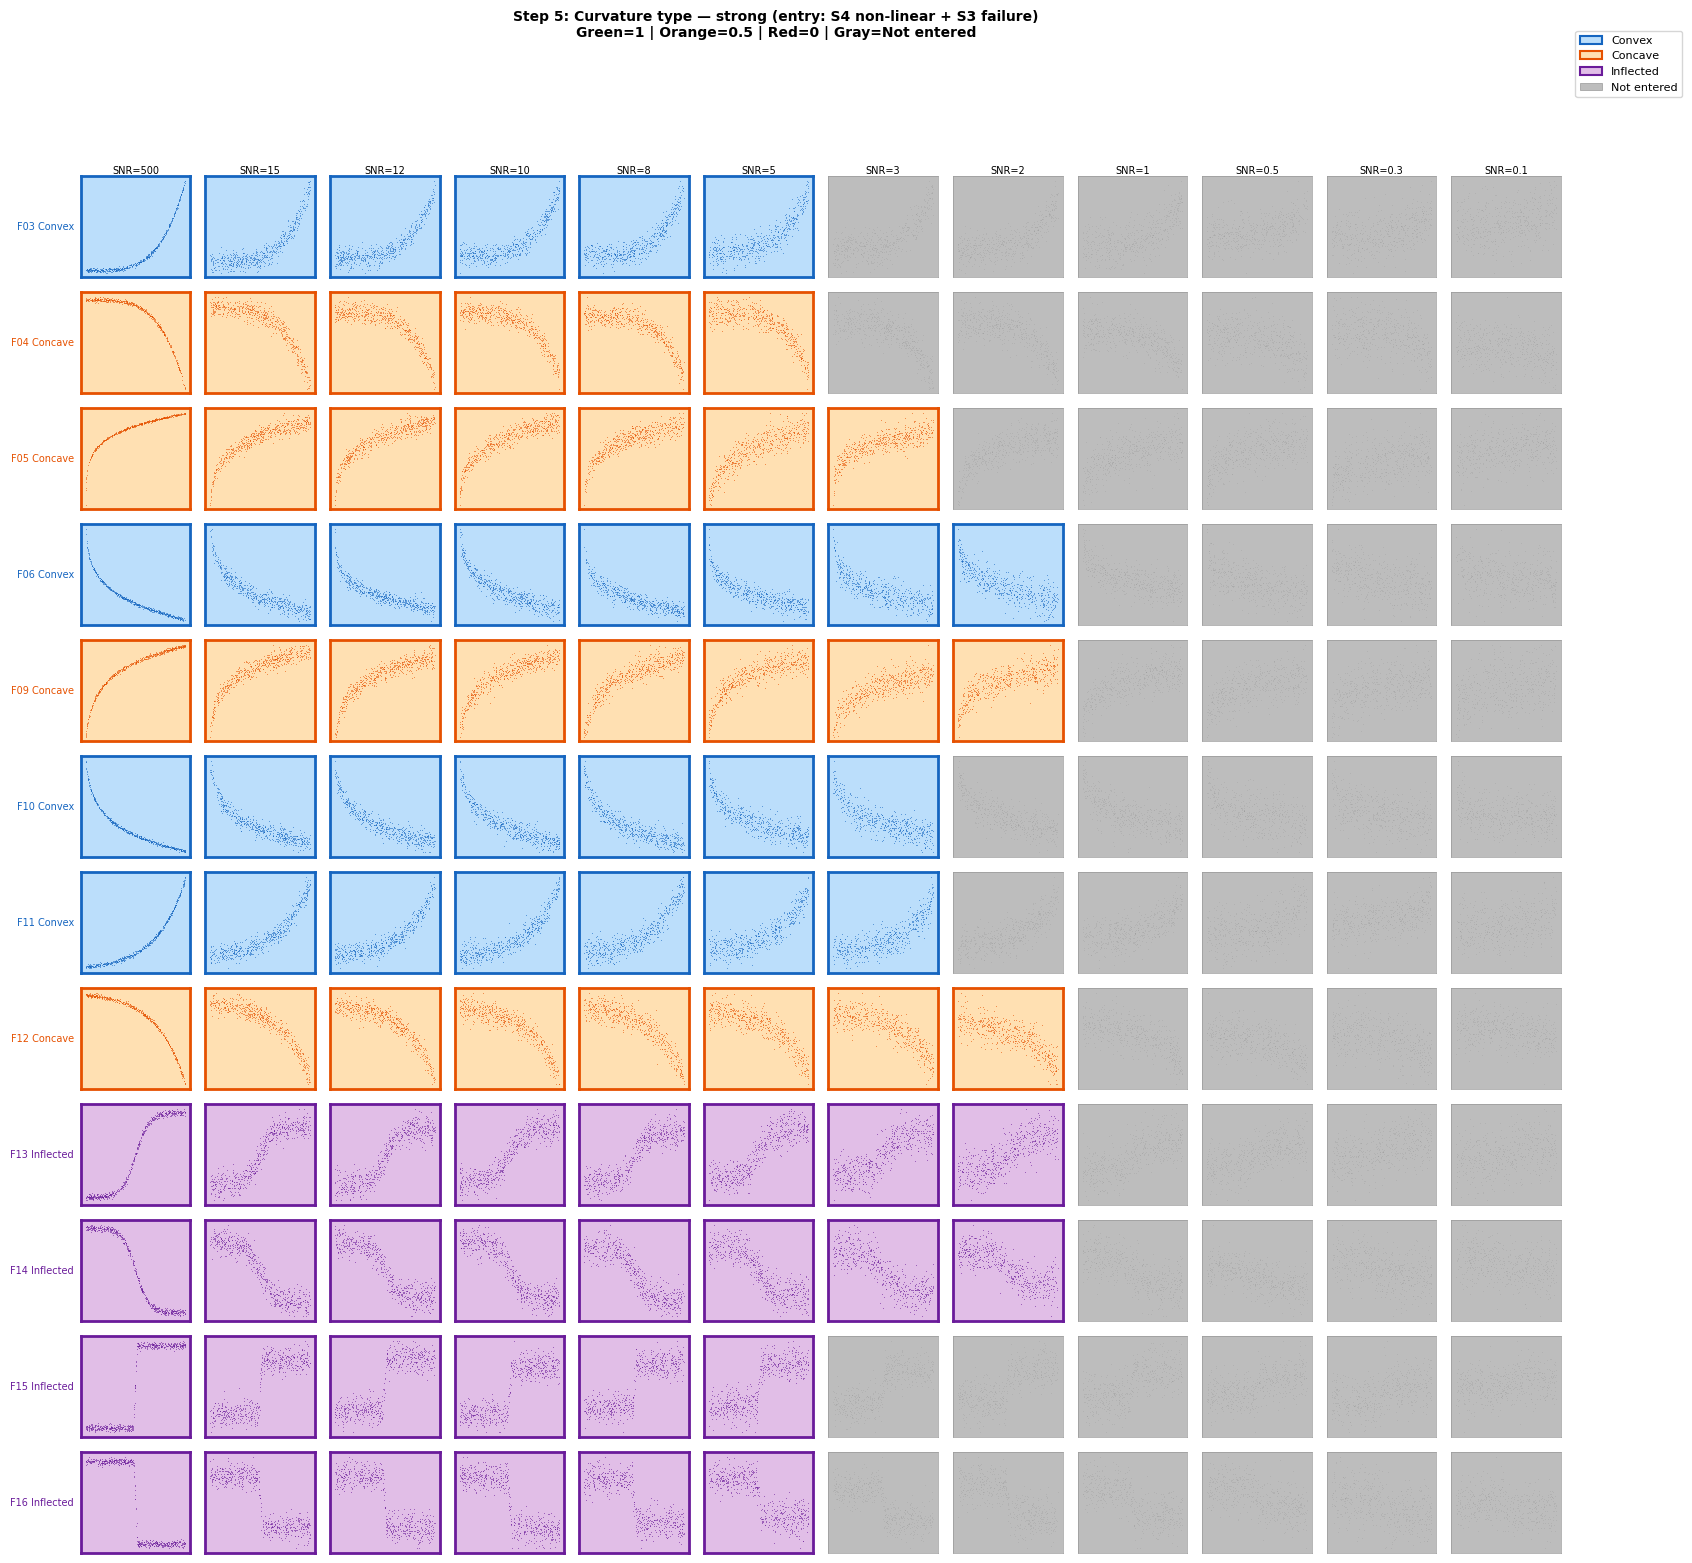

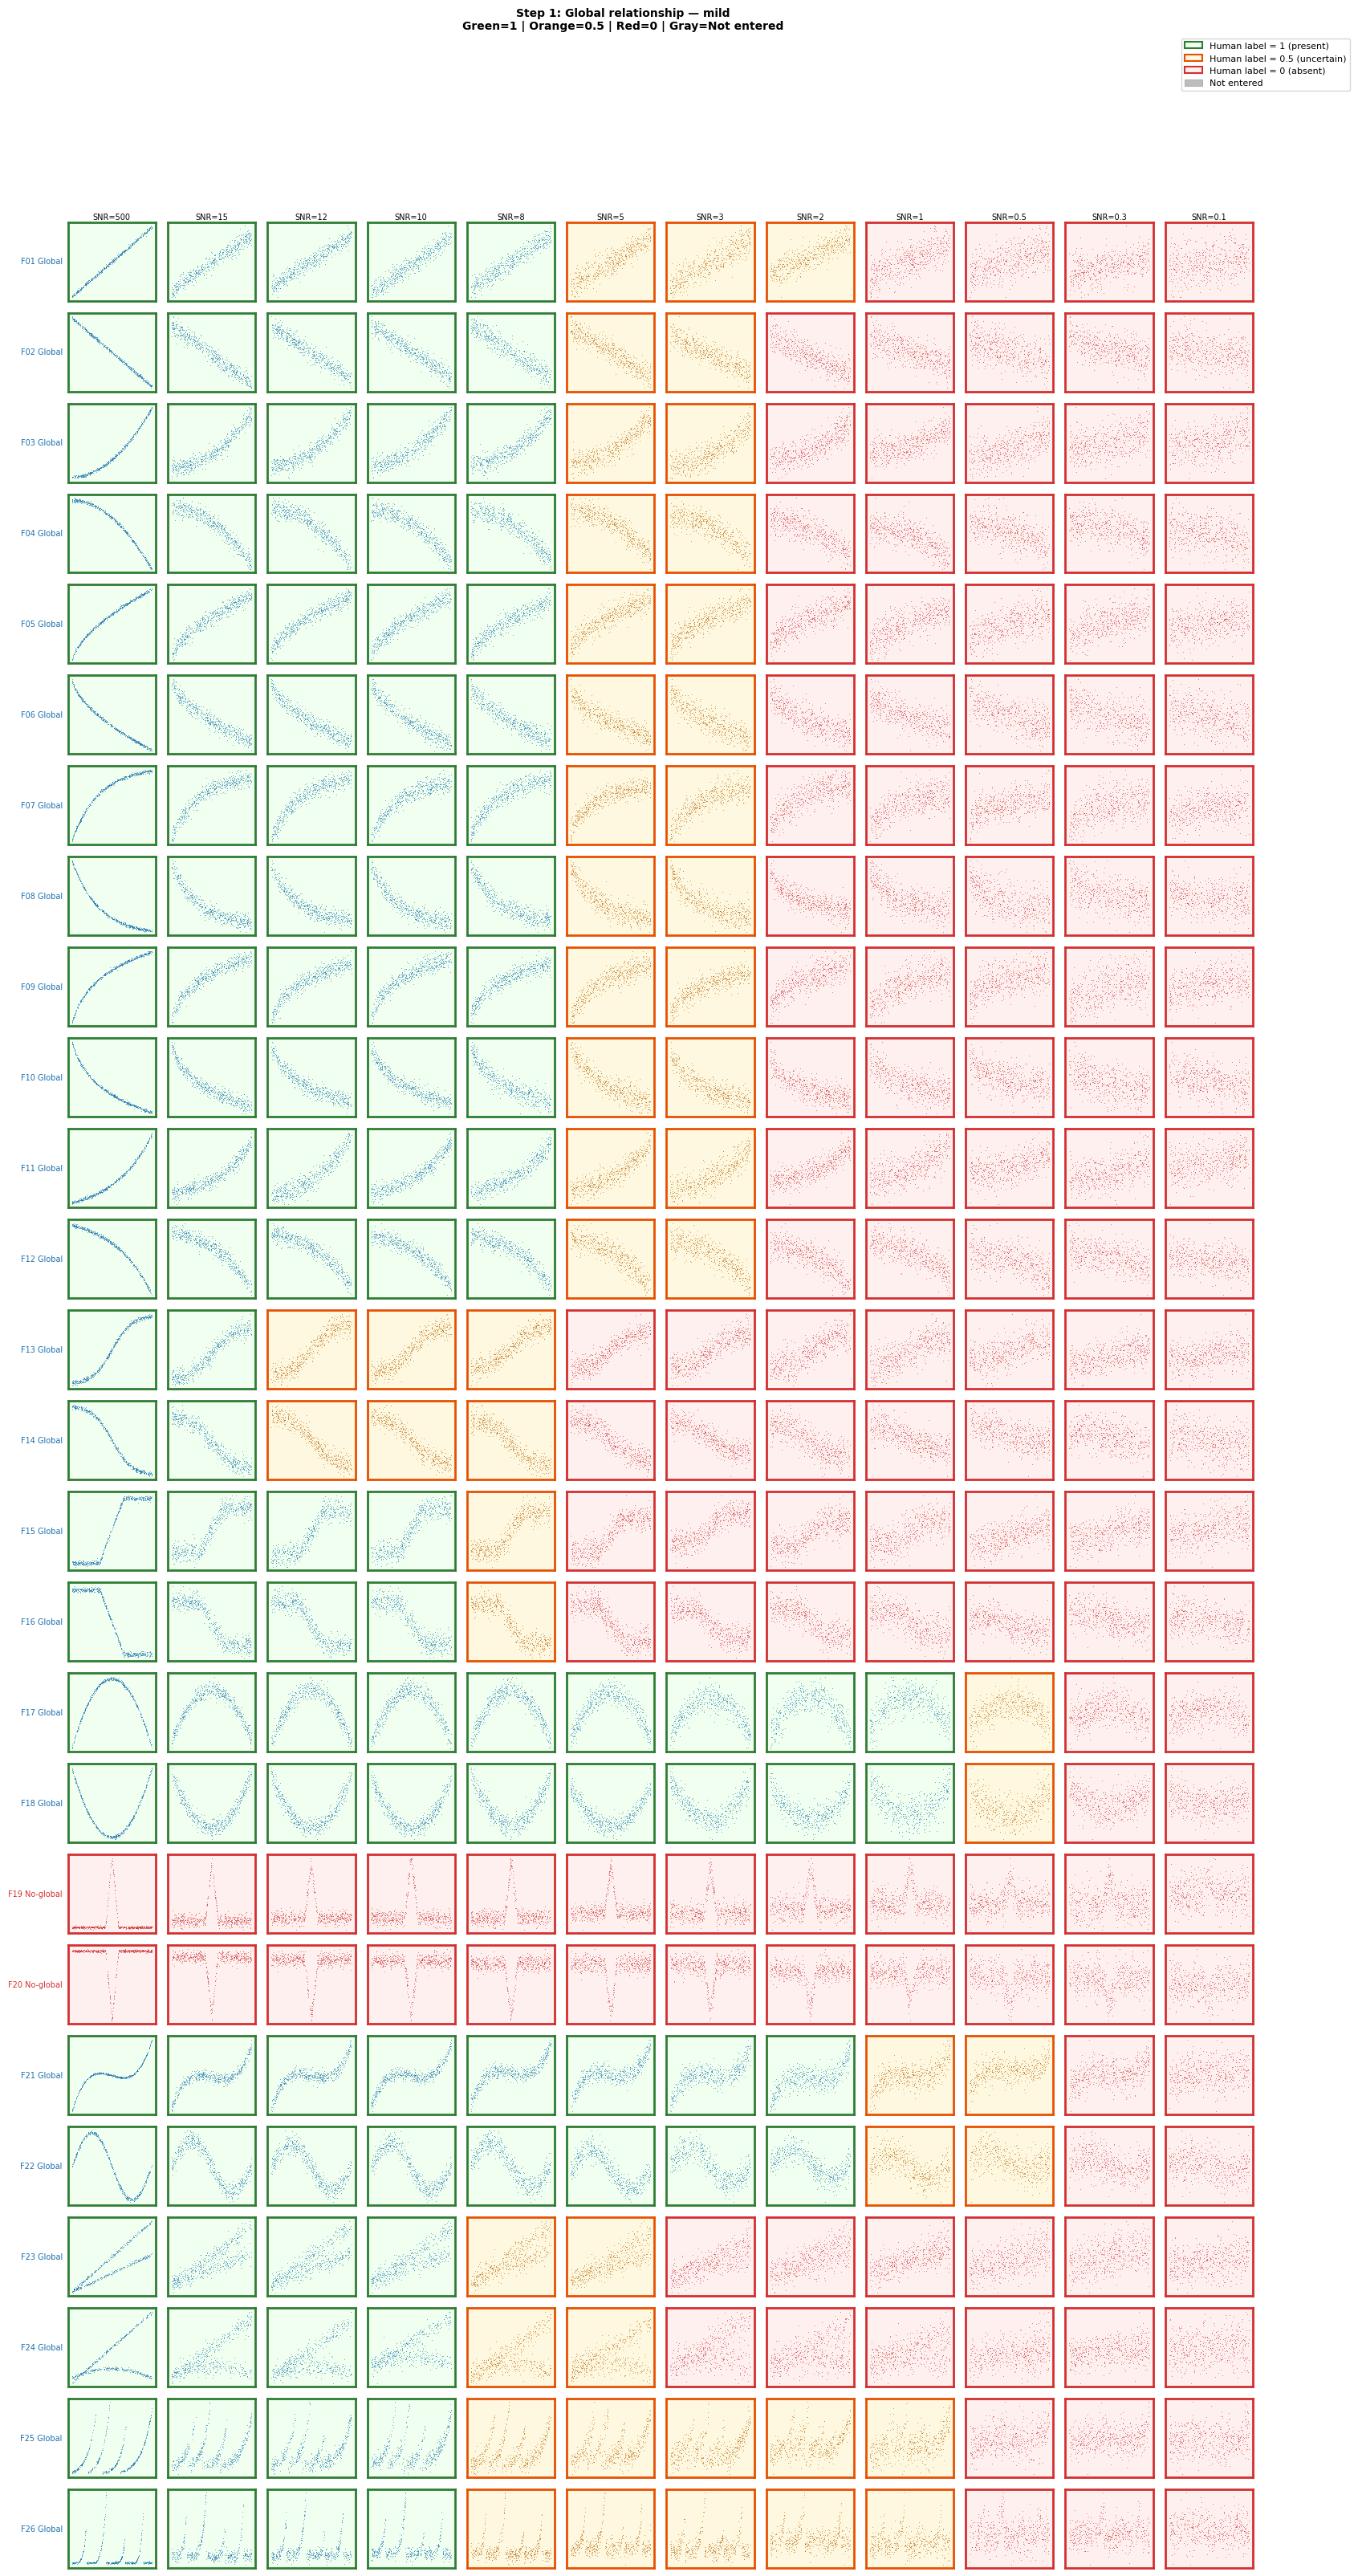

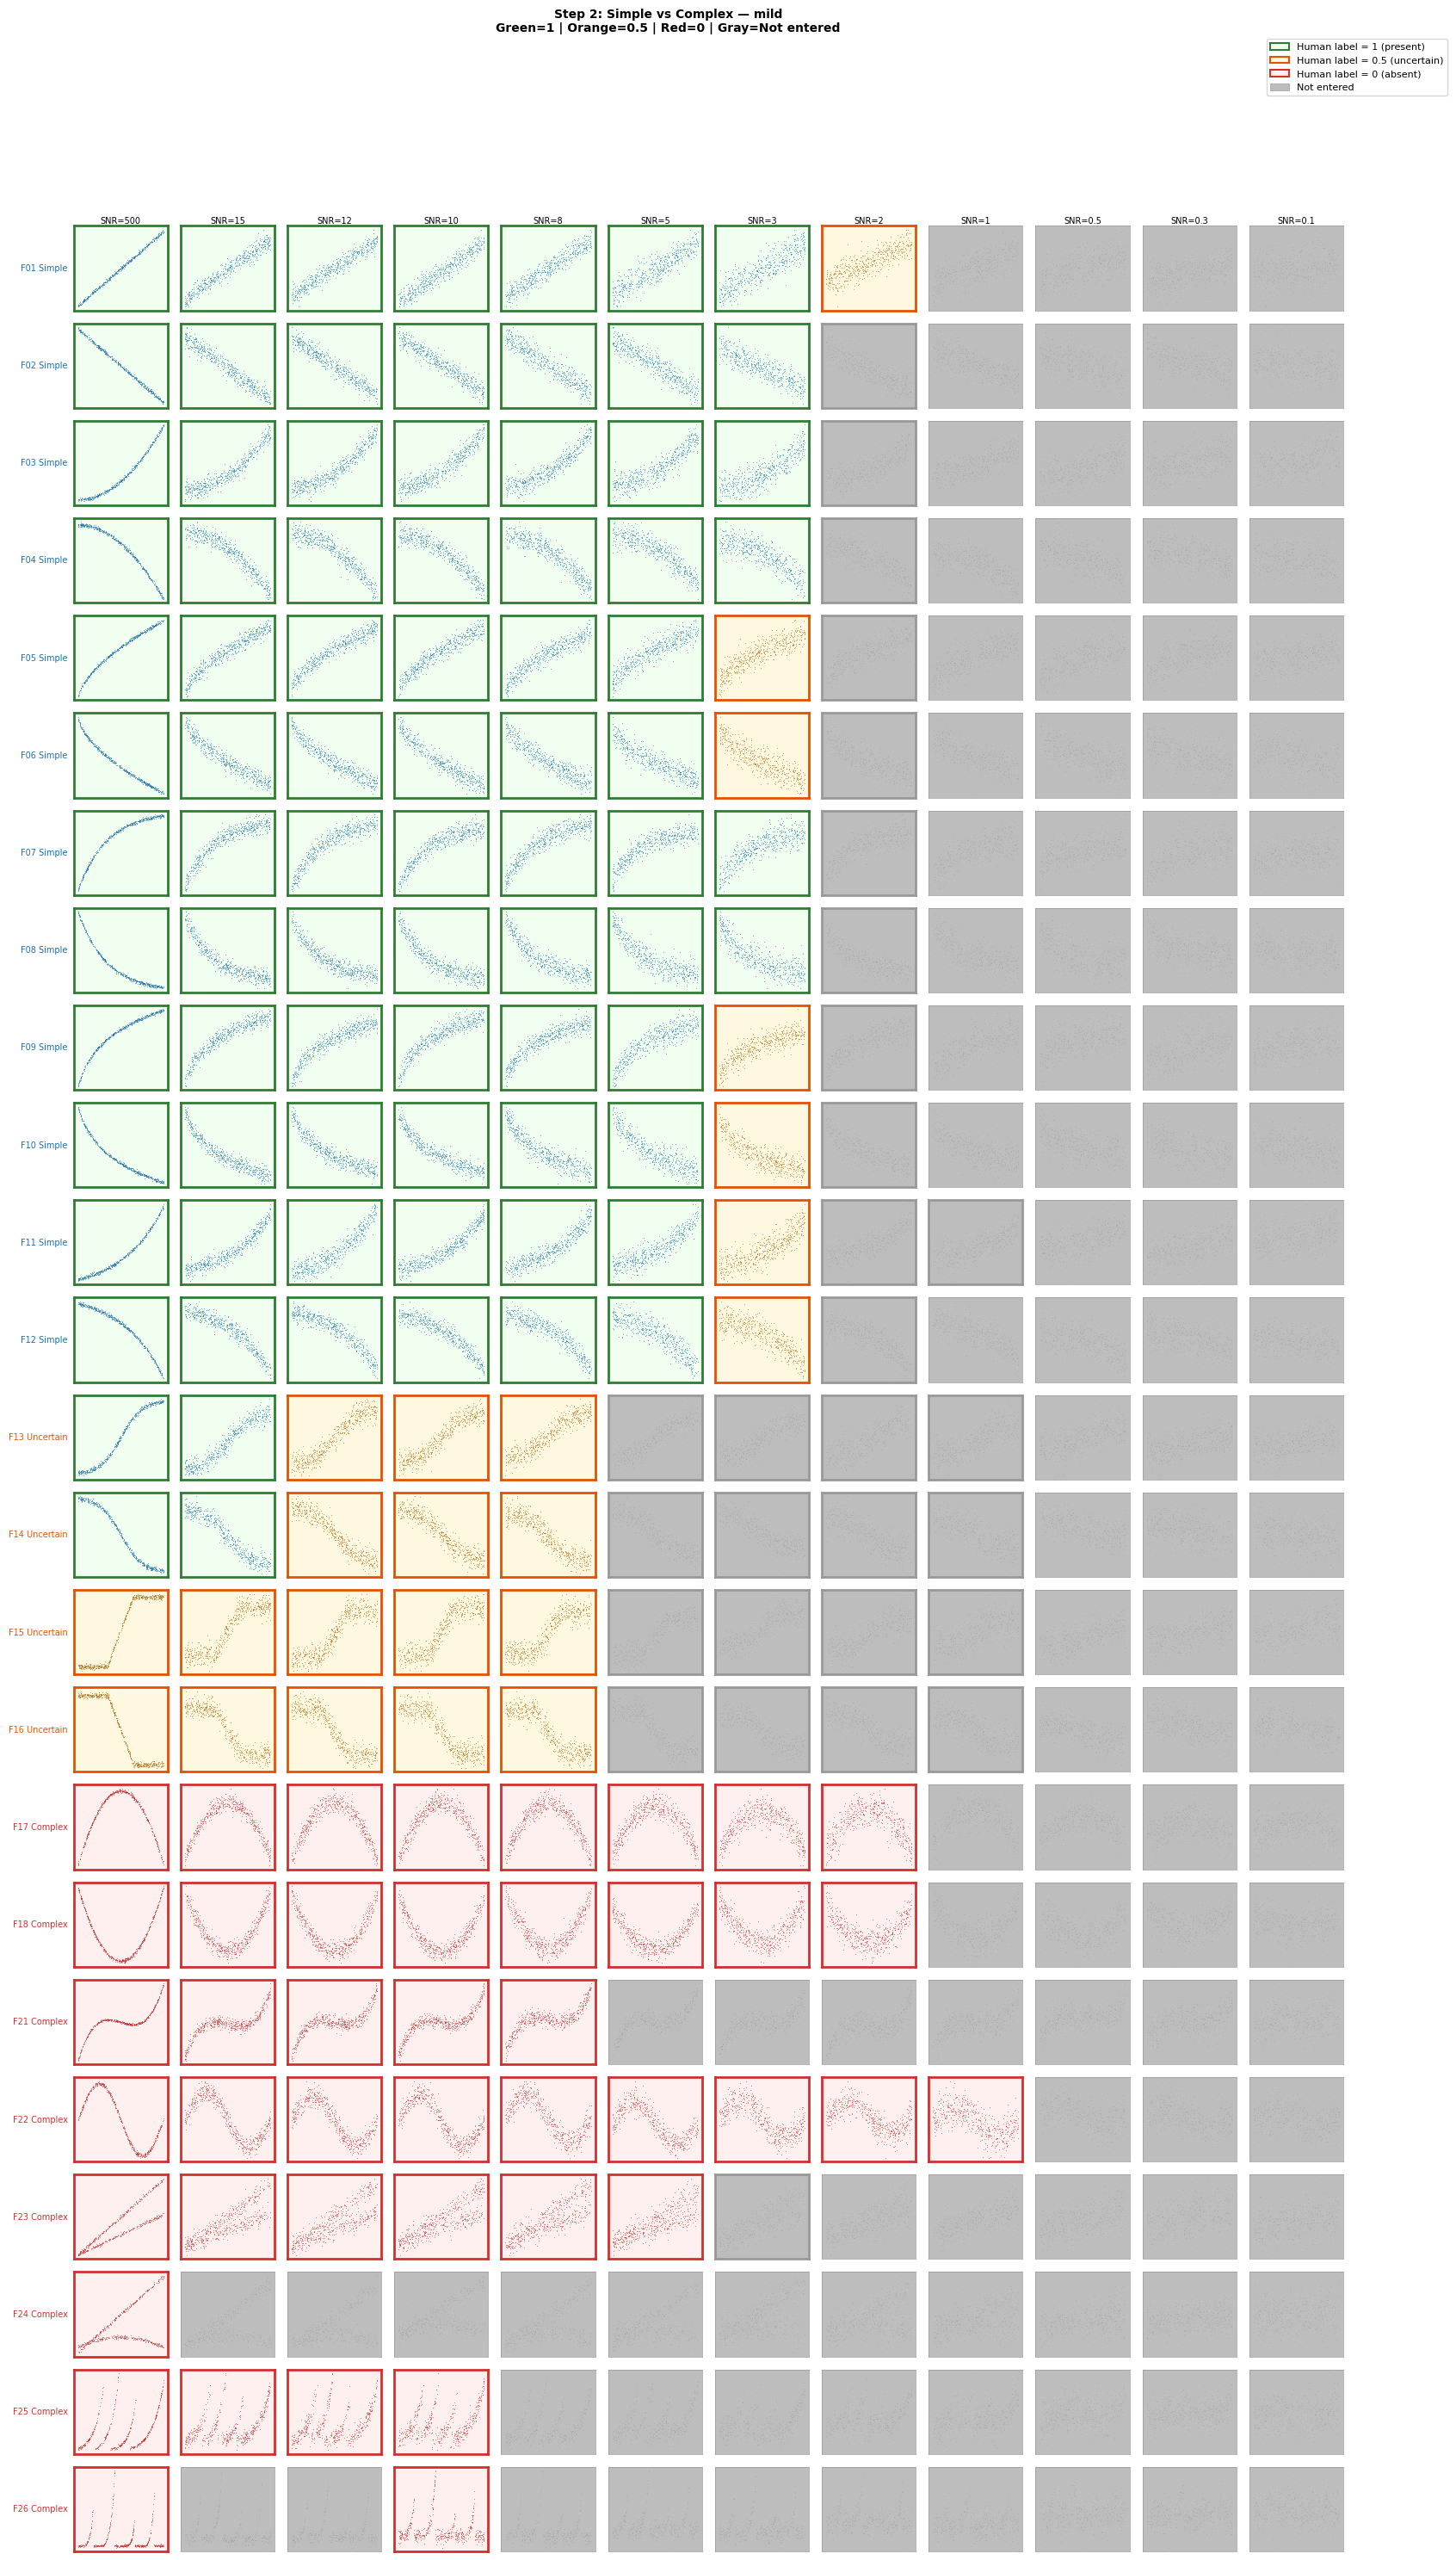

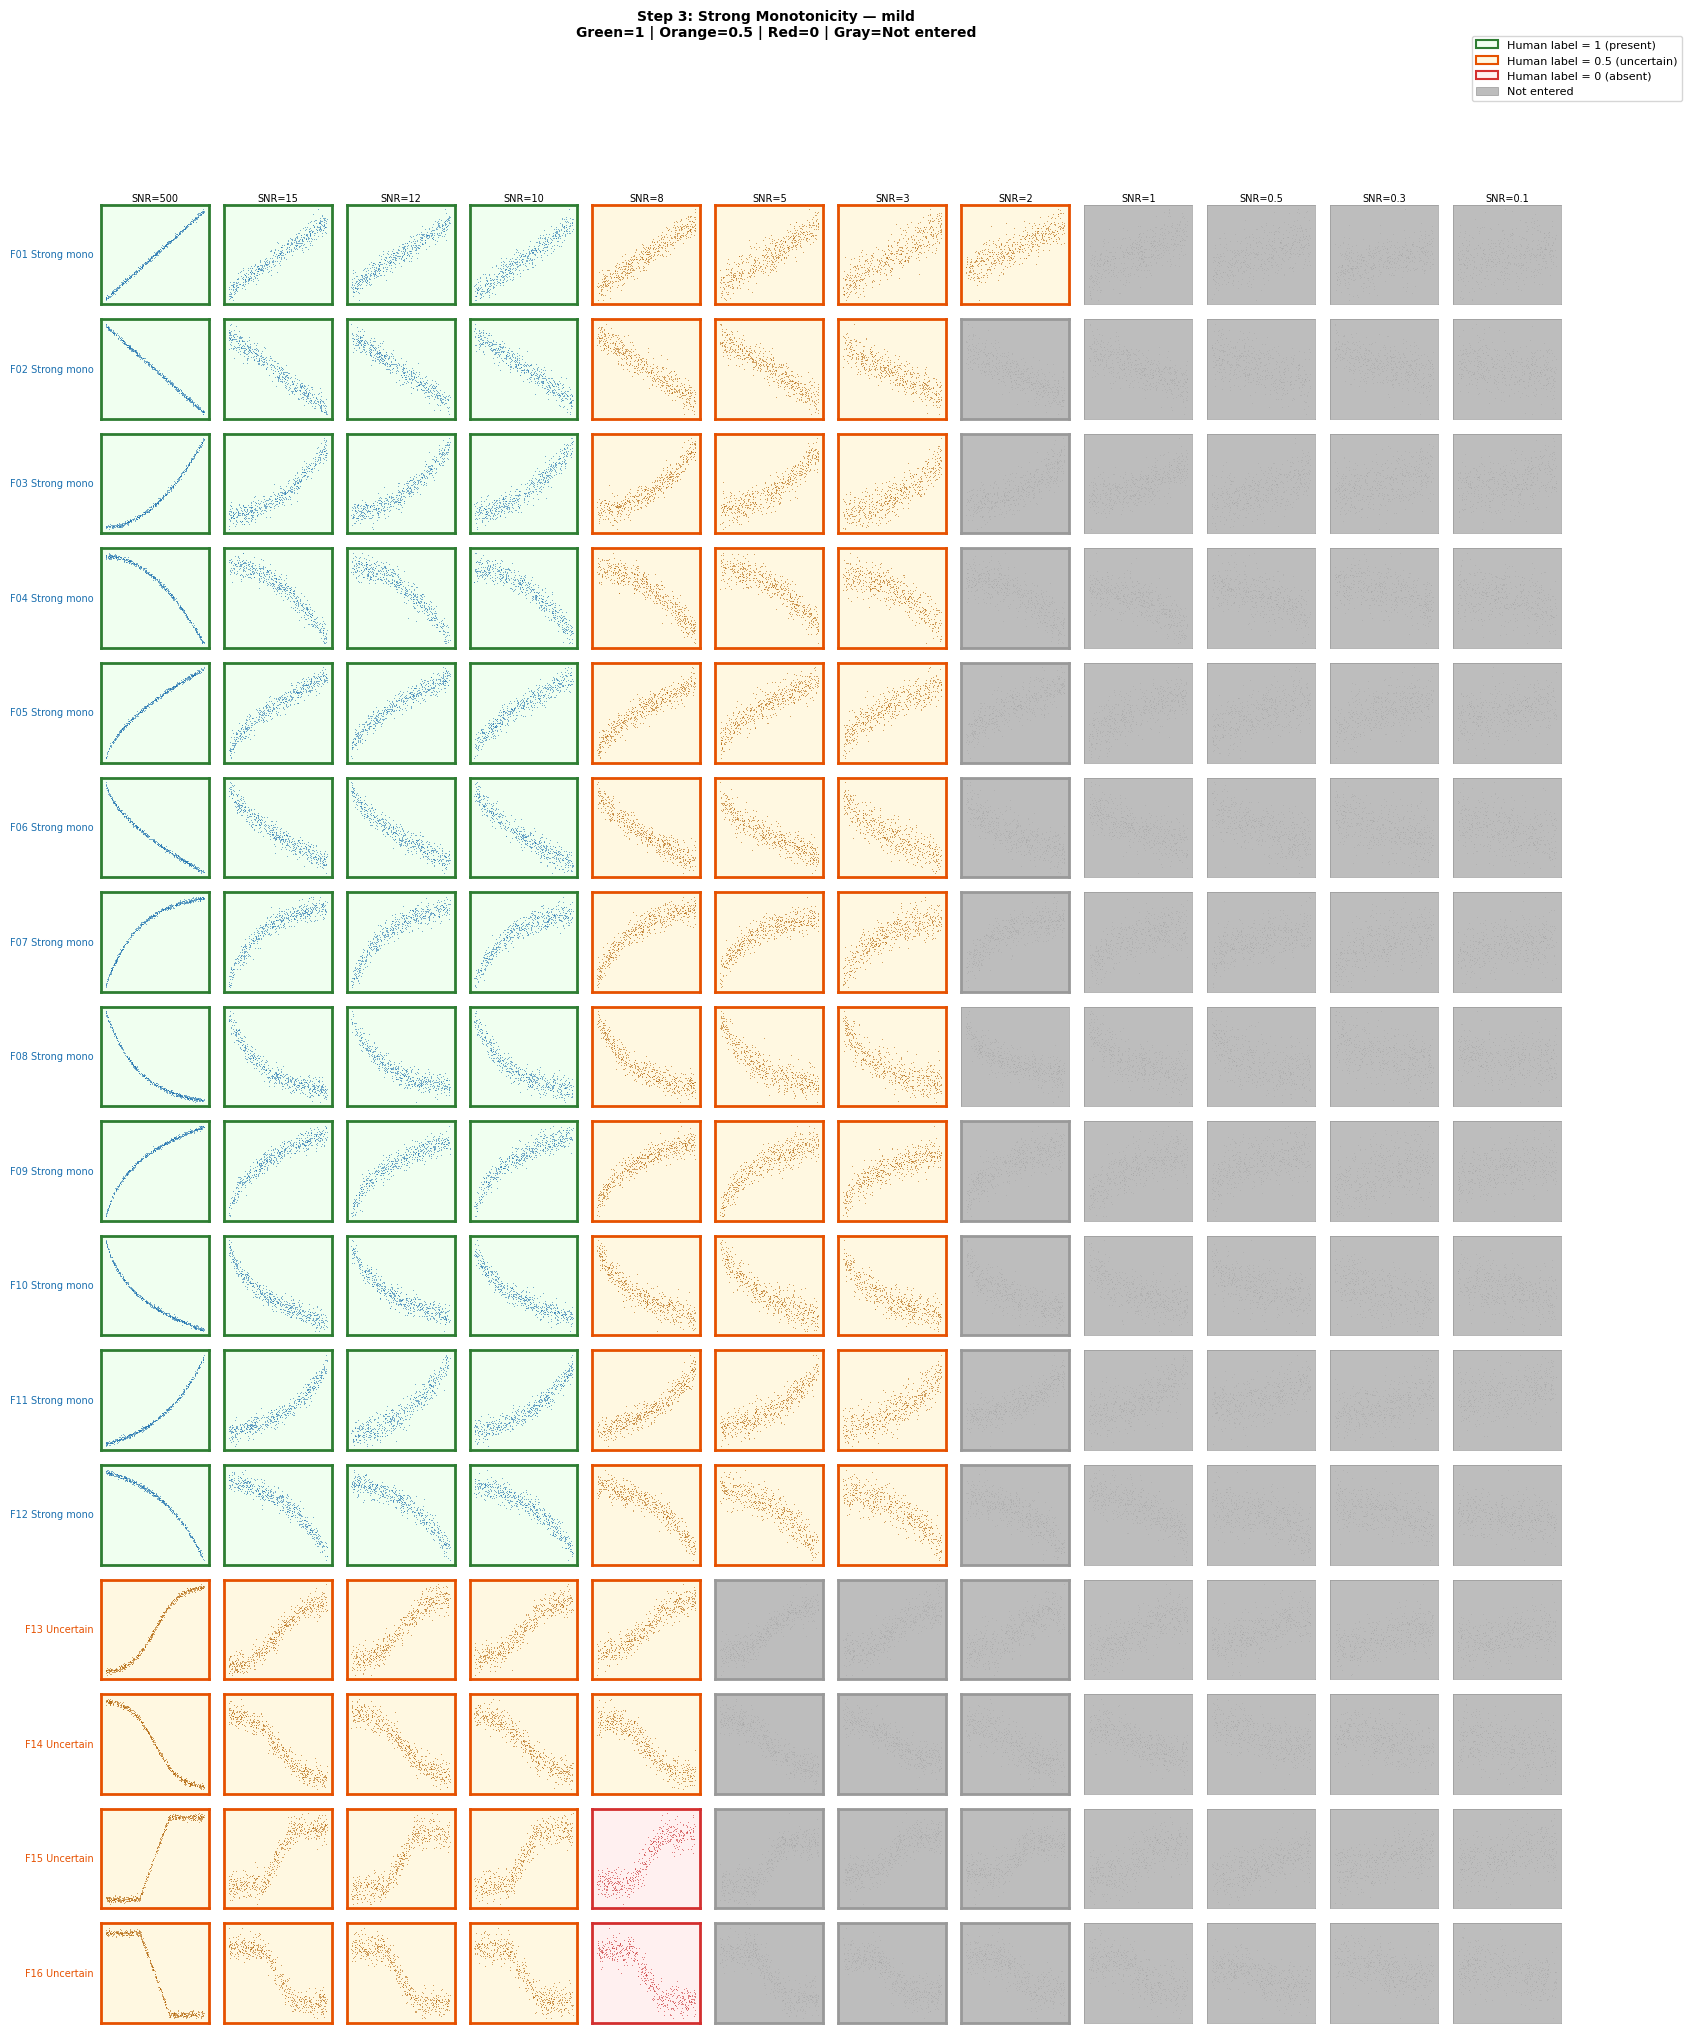

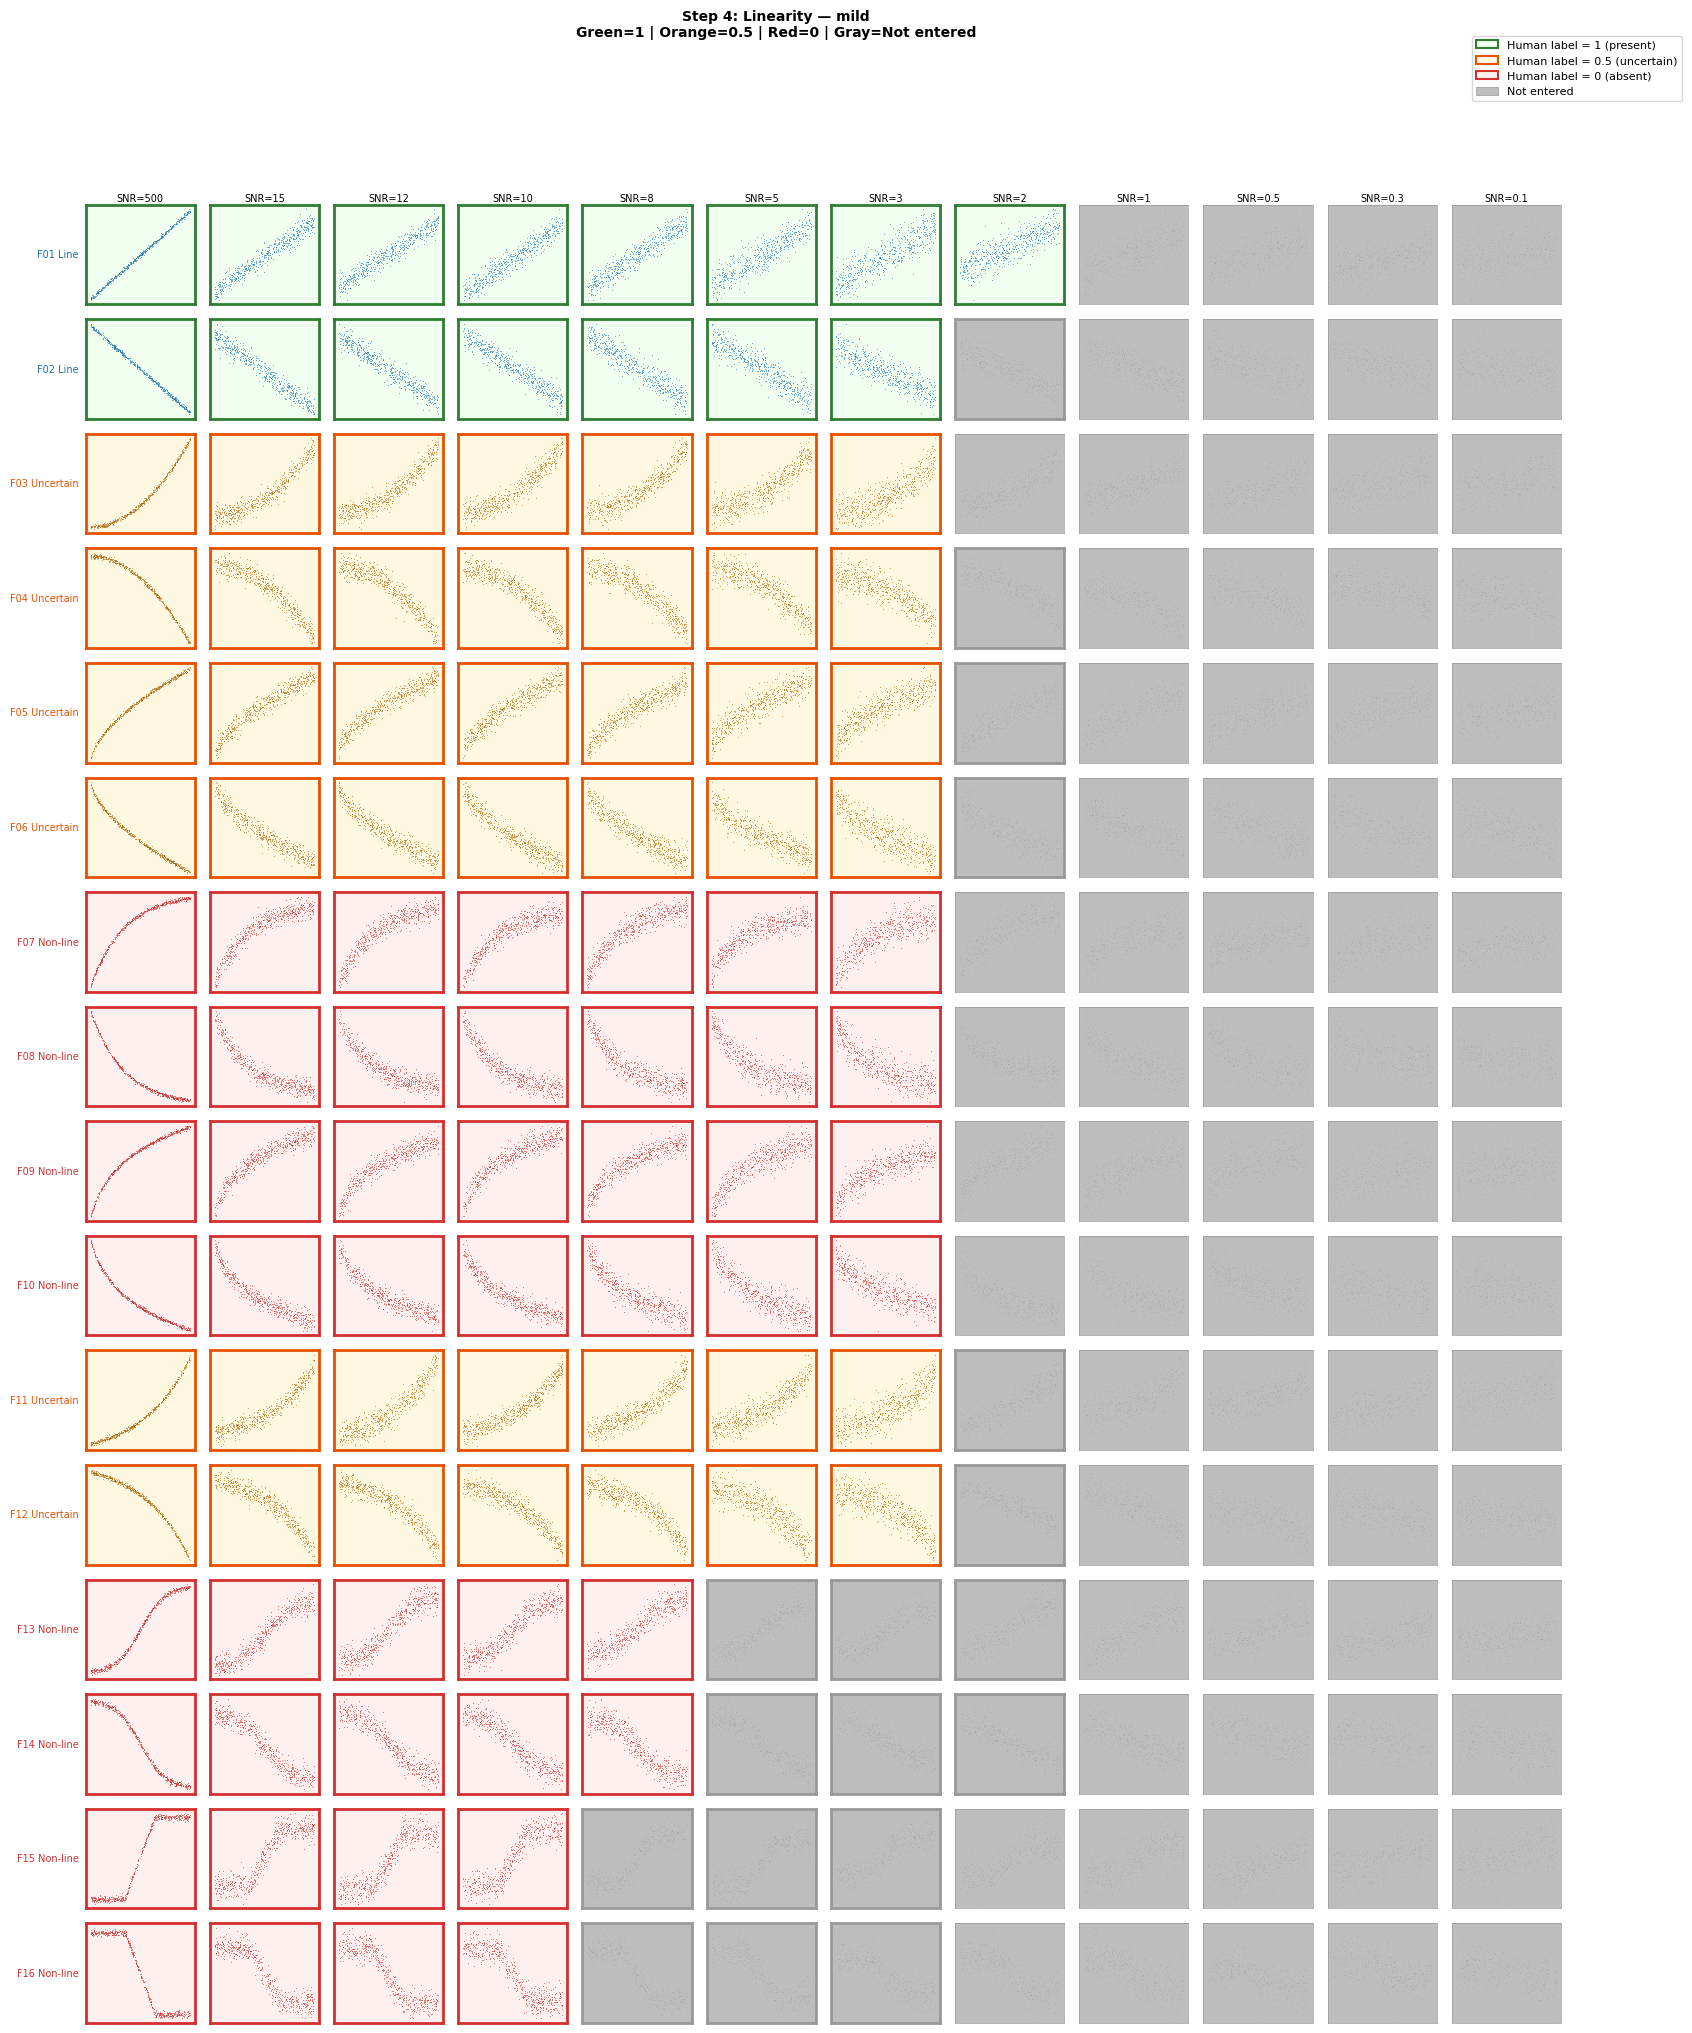

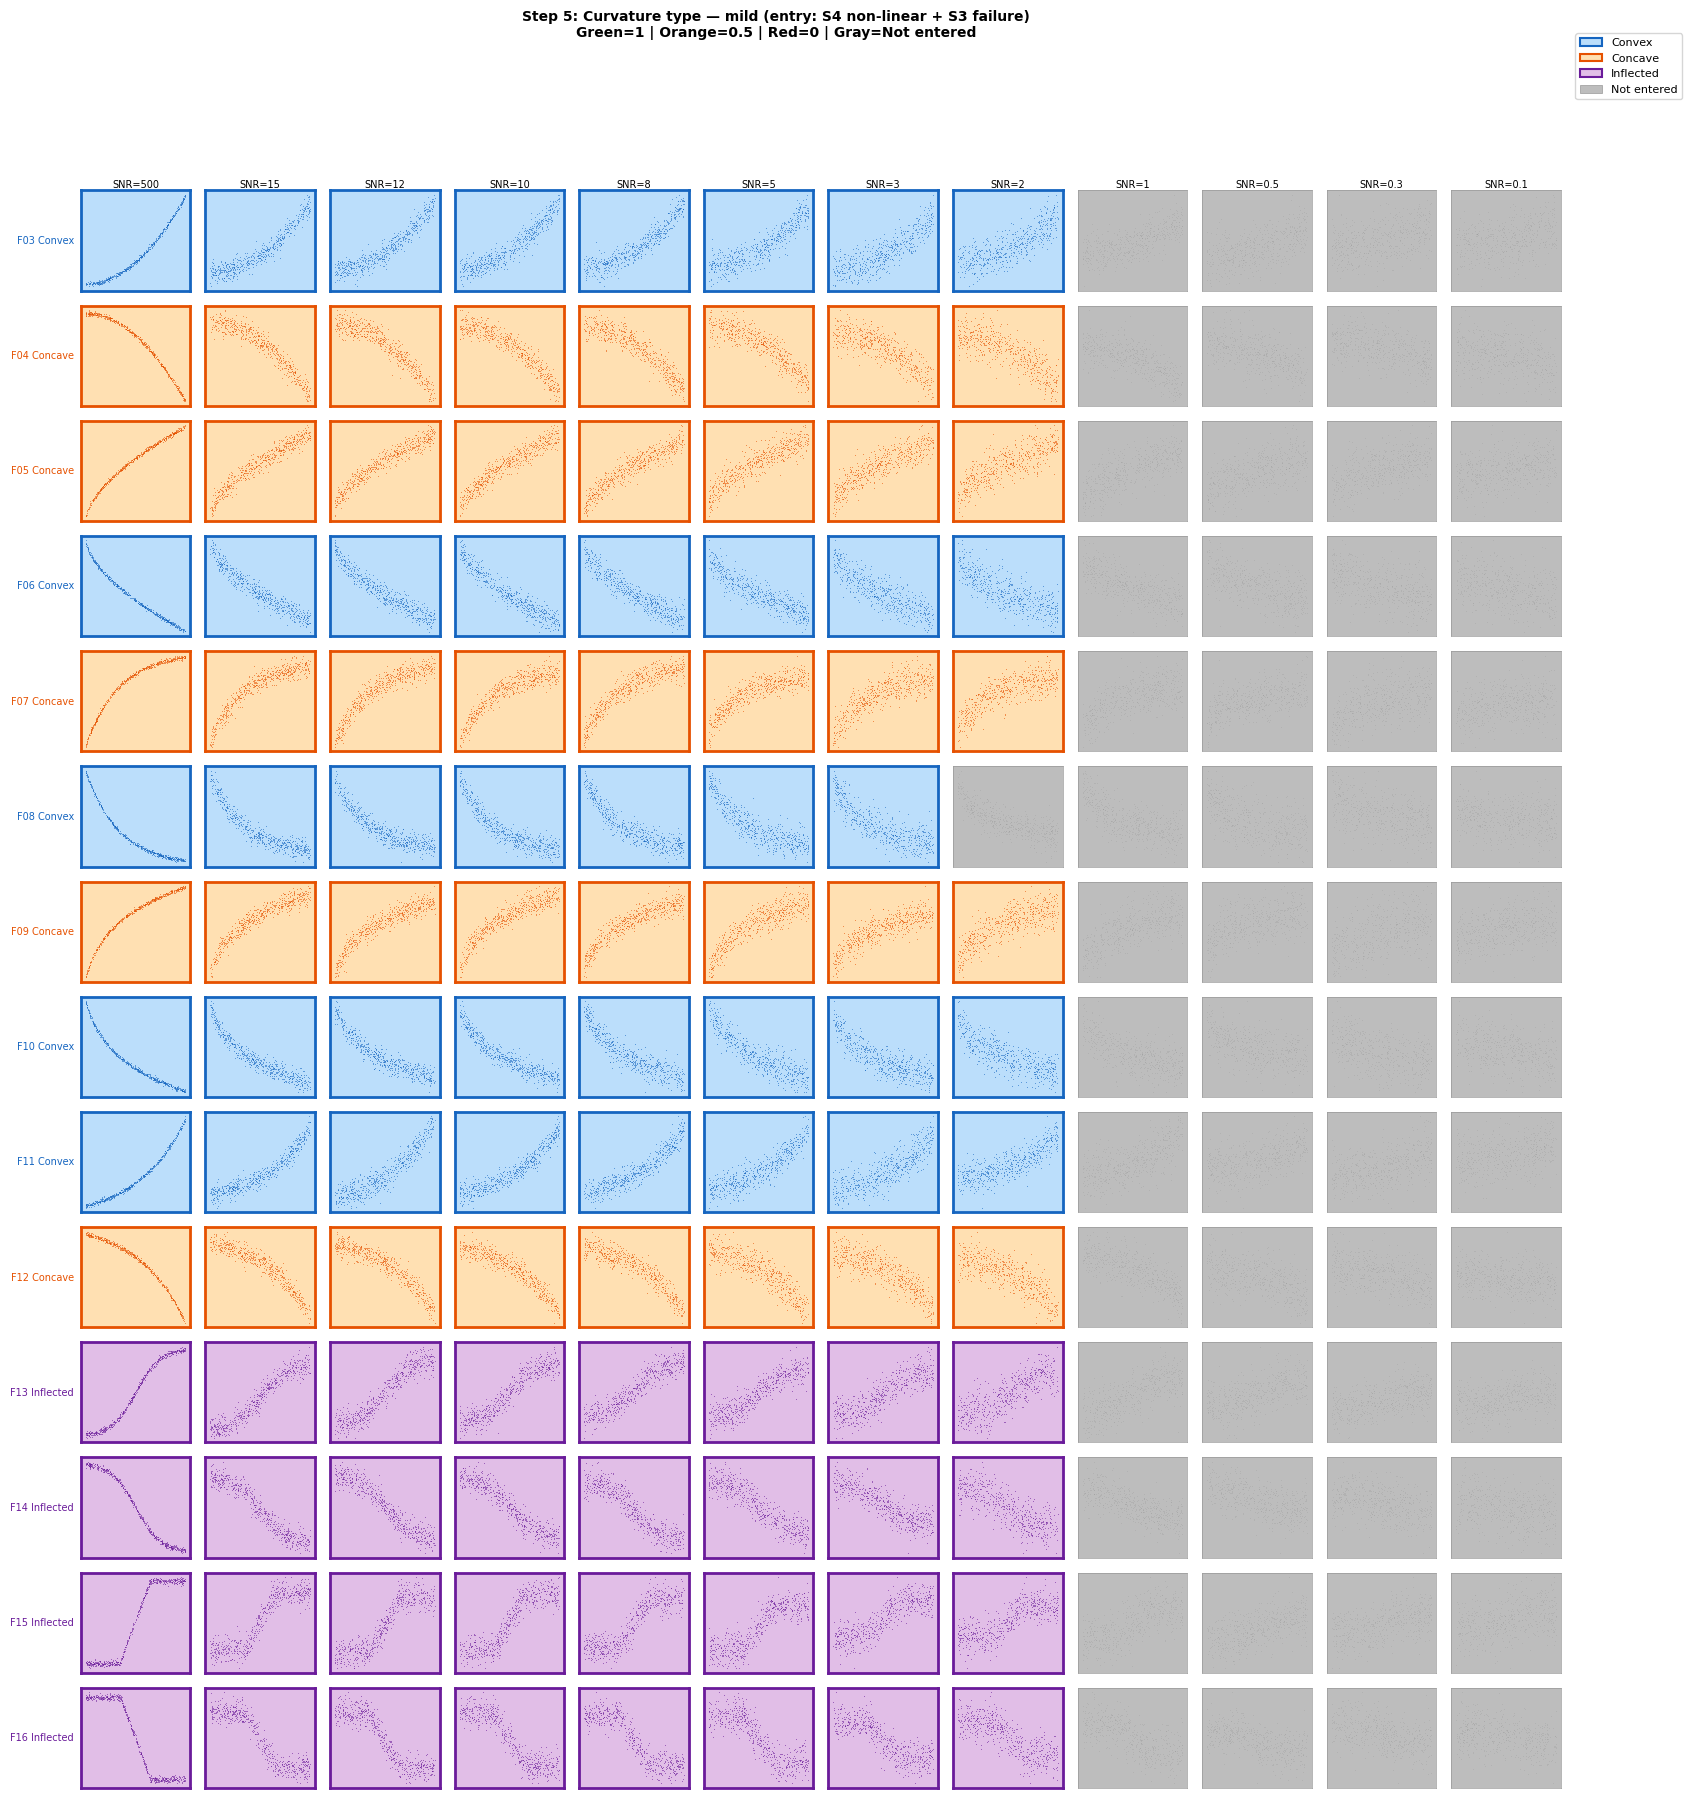

In [10]:
# ══════════════════════════════════════════════════════
#  Per-step scatter grid — both variants
#  Three-color scheme taken directly from each human label:
#    Green  = present (1)
#    Orange = uncertain (0.5)
#    Red    = absent (0)
#    Gray   = didn't pass fuzzy routing for prior steps
#  Step 5: two entry paths (S4 non-linear + S3 failure)
# ══════════════════════════════════════════════════════

CLR = {
    'green_bg': '#f0fff0', 'green_bd': '#2e7d32', 'green_pt': '#1a6faf',
    'orange_bg': '#fff8e1', 'orange_bd': '#E65100', 'orange_pt': '#b06000',
    'red_bg': '#fff0f0', 'red_bd': '#d32f2f', 'red_pt': '#c62828',
    'gray_bg': '#bdbdbd', 'gray_bd': '#999', 'gray_pt': '#999999',
}
S5_CLR = {
    'Convex':    ('#bbdefb', '#1565c0', '#1565c0'),
    'Concave':   ('#ffe0b2', '#e65100', '#e65100'),
    'Inflected': ('#e1bee7', '#6a1b9a', '#6a1b9a'),
}

def get_cell_style(group, snr, clear_snr, thresh_snr, entered, curv_class=None):
    if not entered:
        return CLR['gray_bg'], CLR['gray_pt'], CLR['gray_bd'], 0.2
    if group == 'negative':
        return CLR['red_bg'], CLR['red_pt'], CLR['red_bd'], 0.45
    if group == 'uncertain':
        # Optional boundary: F15/F16 are uncertain only at SNR >= 10.
        if clear_snr is not None and snr < clear_snr:
            return CLR['red_bg'], CLR['red_pt'], CLR['red_bd'], 0.45
        return CLR['orange_bg'], CLR['orange_pt'], CLR['orange_bd'], 0.45
    if group == 'curvature' and curv_class:
        bg, pt, bd = S5_CLR.get(curv_class, (CLR['gray_bg'], CLR['gray_pt'], CLR['gray_bd']))
        return bg, pt, bd, 0.45
    if clear_snr is not None and snr >= clear_snr:
        return CLR['green_bg'], CLR['green_pt'], CLR['green_bd'], 0.45
    if thresh_snr is not None and snr <= thresh_snr:
        return CLR['red_bg'], CLR['red_pt'], CLR['red_bd'], 0.45
    return CLR['orange_bg'], CLR['orange_pt'], CLR['orange_bd'], 0.45

def get_human_label_style(label_value, entered):
    # Steps 1-4 must display the label actually used for fuzzy calibration.
    if not entered or not np.isfinite(label_value):
        return CLR['gray_bg'], CLR['gray_pt'], CLR['gray_bd'], 0.2
    if np.isclose(label_value, 1.0):
        return CLR['green_bg'], CLR['green_pt'], CLR['green_bd'], 0.45
    if np.isclose(label_value, 0.5):
        return CLR['orange_bg'], CLR['orange_pt'], CLR['orange_bd'], 0.45
    return CLR['red_bg'], CLR['red_pt'], CLR['red_bd'], 0.45

STEP_NAMES = {1: 'Global relationship', 2: 'Simple vs Complex',
              3: 'Strong Monotonicity', 4: 'Linearity', 5: 'Curvature type'}
STEP_LABELS = {
    1: {'positive': 'Global', 'negative': 'No-global'},
    2: {'positive': 'Simple', 'uncertain': 'Uncertain', 'negative': 'Complex'},
    3: {'positive': 'Strong mono', 'uncertain': 'Uncertain', 'negative': 'Weak mono'},
    4: {'positive': 'Line', 'uncertain': 'Uncertain', 'negative': 'Non-line'},
}
LABEL_COLORS = {
    'positive': '#1a6faf', 'uncertain': '#E65100',
    'negative': '#d32f2f', 'curvature': '#333',
}

TARGET_SNRS = [500, 15, 12, 10, 8, 5, 3, 2, 1, 0.5, 0.3, 0.1]

for vname in ['strong', 'mild']:
    v = variants[vname]
    ann = ANNOT[vname]
    curv_class = ann['CURVATURE_FAMILY_CLASS']

    all_snrs = sorted(v['snr_float'].unique(), reverse=True)
    snr_levels = []
    for t in TARGET_SNRS:
        closest = min(all_snrs, key=lambda s: abs(s - t))
        if closest not in snr_levels:
            snr_levels.append(closest)

    # ── Recompute fuzzy routing ──
    mic_vals = v['MIC'].values
    pred_s1 = pd.Series(fuzzy_mu(mic_vals, results['step1_mic']['L'],
                                  results['step1_mic']['U']) >= ALPHA, index=v.index)
    rho_vals, r_vals = v['abs_rho'].values, v['abs_r'].values
    mu_s2 = fuzzy_and(
        fuzzy_mu(rho_vals, results['step2_rho']['L'], results['step2_rho']['U']),
        fuzzy_mu(r_vals,   results['step2_r']['L'],   results['step2_r']['U']))
    pred_s2 = pred_s1 & (mu_s2 >= ALPHA)
    pred_s3 = pred_s2 & (fuzzy_mu(rho_vals, results['step3_rho']['L'],
                                   results['step3_rho']['U']) >= ALPHA)
    mu_s4_line = fuzzy_and(
        fuzzy_mu(r_vals, results['step4_r']['L'], results['step4_r']['U']),
        1.0 - fuzzy_mu(v['delta_bic'].values,
                        results['step4_bic']['L'], results['step4_bic']['U']))
    pred_s4_line = pred_s3 & (mu_s4_line >= ALPHA)
    pred_s4_nonline = pred_s3 & ~pred_s4_line

    # Step 5 entry: S4 non-linear + S3 failure
    s3_fams_set = set(ann['STRONG_MONO'] + ann['UNCERTAIN_MONO'] + ann['WEAK_MONO'])
    entered_s3 = pred_s2 & v['family_id'].isin(s3_fams_set)
    failed_s3 = entered_s3 & ~pred_s3
    s5_enter = pred_s4_nonline | failed_s3

    # ── Build per-step configs ──
    all_fids = sorted(f for f in v['family_id'].unique() if f != 'Null')

    step_configs = []

    # Step 1
    s1_groups = {fid: ('negative' if fid in ann['NO_GLOBAL'] else 'positive')
                 for fid in all_fids}
    step_configs.append((1, all_fids, s1_groups,
                         ann['CLEAR_SNR_S1'], ann['THRESHOLD_SNR_S1'],
                         pd.Series(True, index=v.index), None))

    # Step 2
    s2_fams = sorted(set(ann['SIMPLE_FAM'] + ann.get('UNCERTAIN_S2', []) + ann['COMPLEX_FAM']))
    s2_groups = {}
    for fid in s2_fams:
        if fid in ann['COMPLEX_FAM']:
            s2_groups[fid] = 'negative'
        elif fid in ann.get('UNCERTAIN_S2', []):
            s2_groups[fid] = 'uncertain'
        else:
            s2_groups[fid] = 'positive'
    step_configs.append((2, s2_fams, s2_groups,
                         ann['CLEAR_SNR_S2'], ann['THRESHOLD_SNR_S2'],
                         pred_s1, None))

    # Step 3
    s3_fams = sorted(set(ann['STRONG_MONO'] + ann.get('UNCERTAIN_MONO', []) + ann['WEAK_MONO']))
    s3_groups = {}
    for fid in s3_fams:
        if fid in ann['WEAK_MONO']:
            s3_groups[fid] = 'negative'
        elif fid in ann.get('UNCERTAIN_MONO', []):
            s3_groups[fid] = 'uncertain'
        else:
            s3_groups[fid] = 'positive'
    s3_display_boundaries = dict(ann['CLEAR_SNR_S3'])
    s3_display_boundaries.update(ann.get('UNCERTAIN_MONO_MIN_SNR', {}))
    step_configs.append((3, s3_fams, s3_groups,
                         s3_display_boundaries, ann['THRESHOLD_SNR_S3'],
                         pred_s2, None))

    # Step 4
    s4_fams = sorted(set(ann['LINEAR_FAM'] + ann.get('UNCERTAIN_LINEAR', []) + ann['NONLINEAR_FAM']))
    s4_groups = {}
    for fid in s4_fams:
        if fid in ann['NONLINEAR_FAM']:
            s4_groups[fid] = 'negative'
        elif fid in ann.get('UNCERTAIN_LINEAR', []):
            s4_groups[fid] = 'uncertain'
        else:
            s4_groups[fid] = 'positive'
    step_configs.append((4, s4_fams, s4_groups,
                         ann['CLEAR_SNR_S4'], ann['THRESHOLD_SNR_S4'],
                         pred_s3, None))

    # Step 5: both entry paths
    s5_fams = sorted(curv_class.keys())
    s5_groups = {fid: 'curvature' for fid in s5_fams}
    step_configs.append((5, s5_fams, s5_groups, {}, {},
                         s5_enter, curv_class))

    # ── Draw grids ──
    for step, families, groups, clear_dict, thresh_dict, enter_mask, curv_cls in step_configs:
        n_fam = len(families)
        n_snr = len(snr_levels)
        if n_fam == 0:
            continue

        cw, ch = 1.3, 1.2
        fig, axes = plt.subplots(n_fam, n_snr,
                                  figsize=(n_snr * cw + 3, n_fam * ch + 1.5),
                                  squeeze=False)

        for i, fid in enumerate(families):
            group = groups[fid]
            cc = curv_cls.get(fid) if curv_cls else None
            c_snr = clear_dict.get(fid)
            t_snr = thresh_dict.get(fid)

            for j, snr in enumerate(snr_levels):
                ax = axes[i][j]
                mask = (v['family_id'] == fid) & np.isclose(v['snr_float'], snr)
                rows_here = v.loc[mask]

                if len(rows_here) == 0:
                    ax.set_facecolor(CLR['gray_bg'])
                    ax.set_xticks([]); ax.set_yticks([])
                    for sp in ax.spines.values():
                        sp.set_color(CLR['gray_bd']); sp.set_linewidth(0.5)
                    if i == 0:
                        snr_lbl = f'{snr:.0f}' if snr >= 1 else f'{snr:.1f}'
                        ax.set_title(f'SNR={snr_lbl}', fontsize=7, pad=2)
                    if j == 0:
                        if step == 5:
                            lbl = f'{fid} {cc}'
                        else:
                            lbl = f'{fid} {STEP_LABELS[step].get(group, "")}'
                        ax.set_ylabel(lbl, fontsize=7, rotation=0,
                                      ha='right', va='center', labelpad=5,
                                      color=CLR['gray_bd'])
                    continue

                entered_rows = rows_here[enter_mask.reindex(rows_here.index, fill_value=False)]
                entered = len(entered_rows) > 0
                rep = entered_rows.iloc[0] if entered else rows_here.iloc[0]
                cid = rep['case_id']

                if step == 5:
                    bg, pt_c, bdr, pt_a = get_cell_style(
                        group, snr, c_snr, t_snr, entered, cc)
                else:
                    label_values = rows_here[f'label_s{step}'].dropna()
                    label_value = float(label_values.iloc[0]) if len(label_values) else np.nan
                    bg, pt_c, bdr, pt_a = get_human_label_style(label_value, entered)

                ax.set_facecolor(bg)
                for sp in ax.spines.values():
                    sp.set_color(bdr)
                    sp.set_linewidth(2.0 if entered else 0.5)

                if cid in case_idx_map:
                    idx = case_idx_map[cid]
                    xp, yp = x_all[idx], y_all[idx]
                    ax.scatter(xp, yp, s=0.5, c=pt_c, alpha=pt_a, linewidths=0)

                ax.set_xticks([]); ax.set_yticks([])

                if i == 0:
                    snr_lbl = f'{snr:.0f}' if snr >= 1 else f'{snr:.1f}'
                    ax.set_title(f'SNR={snr_lbl}', fontsize=7, pad=2)
                if j == 0:
                    if step == 5:
                        lbl = f'{fid} {cc}'
                        lbl_c = S5_CLR.get(cc, (None, None, '#333'))[2]
                    else:
                        lbl = f'{fid} {STEP_LABELS[step].get(group, "")}'
                        lbl_c = LABEL_COLORS.get(group, '#333')
                    ax.set_ylabel(lbl, fontsize=7, rotation=0,
                                  ha='right', va='center', labelpad=5,
                                  color=lbl_c)

        # Legend
        if step == 5:
            handles = []
            for cls, (bg, pt, bd) in S5_CLR.items():
                handles.append(plt.Rectangle((0,0),1,1, fc=bg, ec=bd, lw=1.5, label=cls))
            handles.append(plt.Rectangle((0,0),1,1, fc=CLR['gray_bg'], ec=CLR['gray_bd'],
                           lw=0.5, label='Not entered'))
        else:
            handles = [
                plt.Rectangle((0,0),1,1, fc=CLR['green_bg'], ec=CLR['green_bd'],
                               lw=1.5, label='Human label = 1 (present)'),
                plt.Rectangle((0,0),1,1, fc=CLR['orange_bg'], ec=CLR['orange_bd'],
                               lw=1.5, label='Human label = 0.5 (uncertain)'),
                plt.Rectangle((0,0),1,1, fc=CLR['red_bg'], ec=CLR['red_bd'],
                               lw=1.5, label='Human label = 0 (absent)'),
                plt.Rectangle((0,0),1,1, fc=CLR['gray_bg'], ec=CLR['gray_bd'],
                               lw=0.5, label='Not entered'),
            ]

        entry_note = ' (entry: S4 non-linear + S3 failure)' if step == 5 else ''
        fig.suptitle(f'Step {step}: {STEP_NAMES[step]} — {vname}{entry_note}\n'
                     f'Green=1 | Orange=0.5 | Red=0 | Gray=Not entered',
                     fontsize=10, fontweight='bold')
        fig.legend(handles=handles, loc='upper right', fontsize=8,
                   bbox_to_anchor=(0.99, 0.97))
        plt.tight_layout(rect=[0.08, 0, 0.93, 0.92])
        plt.show()
        print()

In [11]:
# ══════════════════════════════════════════════════════
#  Save combined fuzzy parameters
# ══════════════════════════════════════════════════════

combined_params = {
    'alpha': ALPHA,
    'training': 'combined (strong + mild)',
    'step1_mic': results['step1_mic'],
    'step2_rho': results['step2_rho'],
    'step2_r':   results['step2_r'],
    'step3_rho': results['step3_rho'],
    'step4_r':   {**results['step4_r'], 'operational': True, 'role': 'AND component'},
    'step4_delta_bic': {
        **results['step4_bic'],
        'decreasing': True,
        'definition': 'BIC_linear - min(BIC_quadratic, BIC_cubic)',
        'operational': True,
        'comparison_threshold': STEP4_BIC_THRESHOLD,
        'routing': 'Line iff fuzzy(|r|) >= alpha AND 1-fuzzy(delta_bic) >= alpha',
    },
    'step5_curvature': {
        'fuzzy': False,
        'model': 'global cubic polynomial',
        'interior_margin': INTERIOR_MARGIN_S5,
        'absolute_f2_tolerance': F2_ABS_TOL_S5,
        'relative_f2_tolerance': F2_REL_TOL_S5,
        'minimum_sign_support': F2_MIN_SIGN_SUPPORT_S5,
        'minimum_active_support': F2_MIN_ACTIVE_SUPPORT_S5,
        'routing': (
            'consistently positive f2 → Convex; '
            'consistently negative f2 → Concave; '
            'meaningful interior f2 sign change → Inflected; '
            'weak or unstable pattern → Uncertain'
        ),
    },
}

out_path = OUT_DIR / 'fuzzy_params_combined.json'
with open(out_path, 'w') as f:
    json_mod.dump(combined_params, f, indent=2)
print(f'Saved to {out_path}')
print(json_mod.dumps(combined_params, indent=2))

Saved to output/S3_polyfit/fuzzy_params_combined.json
{
  "alpha": 0.5,
  "training": "combined (strong + mild)",
  "step1_mic": {
    "L": 0.15000000000000002,
    "U": 0.9600000000000003,
    "mse": 0.059619273984894694
  },
  "step2_rho": {
    "L": 0.5600000000000003,
    "U": 0.9800000000000011,
    "mse": 0.048839355823358147
  },
  "step2_r": {
    "L": 0.5600000000000003,
    "U": 0.9700000000000004,
    "mse": 0.060435240603360633
  },
  "step3_rho": {
    "L": 0.6400000000000003,
    "U": 1.0000000000000058,
    "mse": 0.07722099953805499
  },
  "step4_r": {
    "L": 0.9300000000000004,
    "U": 1.0000000000000004,
    "mse": 0.1078050160703404,
    "operational": true,
    "role": "AND component"
  },
  "step4_delta_bic": {
    "L": -3.0,
    "U": 26.5,
    "mse": 0.05087387156367748,
    "decreasing": true,
    "definition": "BIC_linear - min(BIC_quadratic, BIC_cubic)",
    "operational": true,
    "comparison_threshold": 6.0,
    "routing": "Line iff fuzzy(|r|) >= alpha AN